# Tarea 2
## Alumno: Vicente Allenedes
## Profesor: Dr. Alejandro Veloz

# 1. Red neuronal feedforward desde cero (from scratch)

## Generación del Dataset

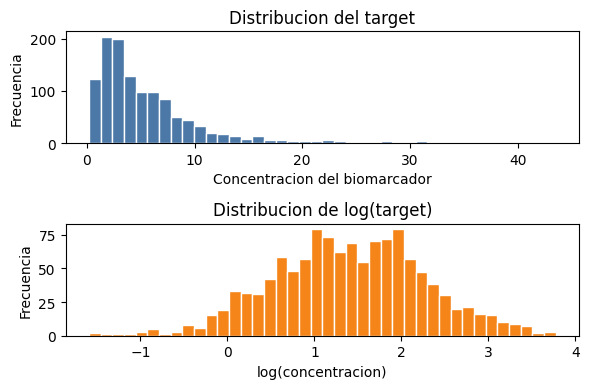

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generar_datos_biomarcador(n=1200, ruido=0.25, seed=42):
    rng = np.random.default_rng(seed)

    edad = rng.uniform(18, 90, size=n)
    dosis = rng.uniform(0, 1, size=n)
    horas = rng.uniform(0, 24, size=n)
    indice_riesgo = rng.normal(0, 1, size=n)
    inflamacion_base = rng.gamma(shape=2.0, scale=1.0, size=n)

    X = np.column_stack([
        edad,
        dosis,
        horas,
        indice_riesgo,
        inflamacion_base,
    ])

    # Funcion latente no lineal. La variable observada se genera como positiva.
    g = (
        -1.2
        + 0.018 * edad
        + 1.4 * np.sin(np.pi * dosis)
        + 0.03 * horas
        + 0.55 * indice_riesgo
        + 0.35 * np.sqrt(inflamacion_base)
        - 0.015 * dosis * horas
    )

    y = np.exp(g + rng.normal(0, ruido, size=n))

    columnas = ["edad", "dosis", "horas", "indice_riesgo", "inflamacion_base"]
    return pd.DataFrame(X, columns=columnas), y

X, y = generar_datos_biomarcador()

fig, axes = plt.subplots(2, 1, figsize=(6, 4))

axes[0].hist(y, bins=40, color="#4c78a8", edgecolor="white")
axes[0].set_title("Distribucion del target")
axes[0].set_xlabel("Concentracion del biomarcador")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(np.log(y), bins=40, color="#f58518", edgecolor="white")
axes[1].set_title("Distribucion de log(target)")
axes[1].set_xlabel("log(concentracion)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [2]:
# 1. Convertir a NumPy arrays y transponer
X_recargada = X.to_numpy().T
y_recargada = y.reshape(1, -1)

# Verificamos las nuevas dimensiones
print("Nuevas dimensiones de X:", X_recargada.shape)
print("Nuevas dimensiones de y:", y_recargada.shape)

Nuevas dimensiones de X: (5, 1200)
Nuevas dimensiones de y: (1, 1200)


Particion

In [3]:
num_ejemplos = X_recargada.shape[1]

# Mezclar los índices
indices = np.arange(num_ejemplos)
np.random.seed(42)
np.random.shuffle(indices)

# Partición
limite_train = int(0.7 * num_ejemplos)
limite_val = int(0.85 * num_ejemplos)

indices_train = indices[:limite_train]
indices_val = indices[limite_train:limite_val]
indices_test = indices[limite_val:]

# Separar los conjuntos
X_train, y_train = X_recargada[:, indices_train], y_recargada[:, indices_train]
X_val, y_val = X_recargada[:, indices_val], y_recargada[:, indices_val]
X_test, y_test = X_recargada[:, indices_test], y_recargada[:, indices_test]

# Estandarizar
media_train = np.mean(X_train, axis=1, keepdims=True)
desviacion_train = np.std(X_train, axis=1, keepdims=True)

X_train_scal = (X_train - media_train) / desviacion_train
X_val_scal = (X_val - media_train) / desviacion_train
X_test_scal = (X_test - media_train) / desviacion_train

Inicialización de los pesos con He

In [4]:
def inicializar_parametros_he(n_x, n_h, n_y=1, seed=42):
    """
    Inicializa los pesos usando el método de He (Kaiming) para las capas con ReLU,
    y los sesgos en cero.
    """
    rng = np.random.default_rng(seed)

    # Capa 1 (Entrada -> Oculta)
    # Los pesos tienen dimensión (n_h, n_x) para cumplir con Z1 = W1 * X + B1
    W1 = rng.normal(0, np.sqrt(2.0 / n_x), size=(n_h, n_x))
    b1 = np.zeros((n_h, 1))

    # Capa 2 (Oculta -> Salida)
    # Como la capa de salida es lineal (regresión estándar para empezar),
    # podemos usar una escala similar basada en n_h.
    W2 = rng.normal(0, np.sqrt(2.0 / n_h), size=(n_y, n_h))
    b2 = np.zeros((n_y, 1))

    parametros = {
        "W1": W1, "b1": b1,
        "W2": W2, "b2": b2
    }
    return parametros

ReLU

In [5]:
def relu(Z):
    """Función de activación ReLU elemento a elemento."""
    return np.maximum(0, Z)

def relu_derivada(Z):
    """Derivada de la función ReLU para el backpropagation."""
    # Retorna 1 si Z > 0, de lo contrario 0 (convertido a flotante)
    return (Z > 0).astype(float)

Forward Pass

In [6]:
def forward_pass(X, parametros):
    """
    Realiza la propagación hacia adelante a través de la red de 2 capas.
    Capa 1: Oculta (con activación ReLU)
    Capa 2: Salida lineal (Regresión)
    """
    W1, b1 = parametros["W1"], parametros["b1"]
    W2, b2 = parametros["W2"], parametros["b2"]

    # Capa 1: Entrada -> Oculta
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)  # Aquí usamos la función ReLU que definimos antes

    # Capa 2: Oculta -> Salida
    Z2 = np.dot(W2, A1) + b2
    A2 = Z2  # Activación lineal para regresión estándar

    # Guardamos los valores intermedios porque los necesitaremos en el Backprop
    cache = {
        "Z1": Z1, "A1": A1,
        "Z2": Z2, "A2": A2
    }
    return A2, cache

Perdida
$L(\phi) = \frac{1}{I}\sum_{i=1}^{I} (y_i - f[x_i,\phi])^2$

In [7]:
def calcular_perdida_mse(A2, y):
    """
    Calcula el Error Cuadrático Medio (MSE) entre la predicción y el valor real.
    """
    I = y.shape[1]
    costo = (1.0 / I) * np.sum((A2 - y) ** 2)
    return costo

Backpropagation


In [8]:
def backpropagation(X, y, parametros, cache):
    """
    Implementa el cálculo manual de gradientes capa por capa.
    """
    m = y.shape[1]

    # Recuperar parámetros y valores guardados en la caché
    W2 = parametros["W2"]
    Z1, A1 = cache["Z1"], cache["A1"]
    A2 = cache["A2"]

    # Capa 2: Salida (Regresión MSE)
    # Derivada de la pérdida respecto a Z2: dL/dZ2 = (2/m) * (A2 - y)
    dZ2 = (2.0 / m) * (A2 - y)

    # Gradientes de la Capa 2
    dW2 = np.dot(dZ2, A1.T)
    dB2 = np.sum(dZ2, axis=1, keepdims=True)

    # Capa 1: Oculta (Filtro con la derivada de ReLU)
    # dZ1 = (W2_transpuesta * dZ2) multiplicado elemento a elemento por ReLU'(Z1)
    dZ1 = np.dot(W2.T, dZ2) * relu_derivada(Z1)

    # Gradientes de la Capa 1
    dW1 = np.dot(dZ1, X.T)
    dB1 = np.sum(dZ1, axis=1, keepdims=True)

    gradientes = {
        "dW1": dW1, "db1": dB1,
        "dW2": dW2, "db2": dB2
    }
    return gradientes

Actualizacion

In [9]:
def actualizar_parametros(parametros, gradientes, learning_rate):
    """
    Ajusta los parámetros usando los gradientes calculados.
    """
    parametros["W1"] -= learning_rate * gradientes["dW1"]
    parametros["b1"] -= learning_rate * gradientes["db1"]
    parametros["W2"] -= learning_rate * gradientes["dW2"]
    parametros["b2"] -= learning_rate * gradientes["db2"]

    return parametros

Descenso por mini-batches

In [10]:
def crear_minibatches(X, y, tamaño_batch, seed=None):
    """
    Divide los datos en minibatches aleatorios de tamaño fijo.
    """
    m = X.shape[1]
    minibatches = []

    # Configurar el generador aleatorio para mezclar de forma idéntica X e y
    rng = np.random.default_rng(seed)
    indices = np.arange(m)
    rng.shuffle(indices)

    X_mezclado = X[:, indices]
    y_mezclado = y[:, indices]

    # Calcular cuántos lotes completos tenemos
    num_batches_completos = m // tamaño_batch

    for k in range(num_batches_completos):
        X_batch = X_mezclado[:, k * tamaño_batch : (k + 1) * tamaño_batch]
        y_batch = y_mezclado[:, k * tamaño_batch : (k + 1) * tamaño_batch]
        minibatches.append((X_batch, y_batch))

    # Si quedó un residuo (el último lote es más pequeño), lo agregamos
    if m % tamaño_batch != 0:
        X_batch = X_mezclado[:, num_batches_completos * tamaño_batch :]
        y_batch = y_mezclado[:, num_batches_completos * tamaño_batch :]
        minibatches.append((X_batch, y_batch))

    return minibatches

Entrenamiento red

In [11]:
def entrenar_red_from_scratch(X_train, y_train, X_val, y_val, n_hidden, epocas, tamaño_batch, learning_rate, seed=42):
    """
    Bucle completo de entrenamiento usando descenso de gradiente por minibatches.
    """
    n_features = X_train.shape[0]

    # 1. Inicializar parámetros
    parametros = inicializar_parametros_he(n_features, n_hidden, n_y=1, seed=seed)

    # Diccionario para registrar el historial de pérdidas
    historial = {"train_loss": [], "val_loss": []}

    for epoca in range(1, epocas + 1):
        # Crear minibatches aleatorios en cada época para cambiar el orden
        batches = crear_minibatches(X_train, y_train, tamaño_batch, seed=seed + epoca)

        # Iterar sobre cada minibatch (Entrenamiento activo)
        for X_batch, y_batch in batches:
            # Forward pass con el lote actual
            _, cache = forward_pass(X_batch, parametros)

            # Calcular gradientes con el lote actual
            gradientes = backpropagation(X_batch, y_batch, parametros, cache)

            # Actualizar pesos y sesgos
            parametros = actualizar_parametros(parametros, gradientes, learning_rate)

        # Evaluar el rendimiento global de la época en los conjuntos completos
        A2_train, _ = forward_pass(X_train, parametros)
        loss_train = calcular_perdida_mse(A2_train, y_train)

        A2_val, _ = forward_pass(X_val, parametros)
        loss_val = calcular_perdida_mse(A2_val, y_val)

        # Registrar en el historial
        historial["train_loss"].append(loss_train)
        historial["val_loss"].append(loss_val)

        # Imprimir progreso cada 10 épocas
        if epoca % 10 == 0 or epoca == 1:
            print(f"Época {epoca}/{epocas} -> Pérdida Train: {loss_train:.4f} | Pérdida Val: {loss_val:.4f}")

    return parametros, historial

Entrenamiento

In [12]:
import time

EPOCAS = 150
TAMAÑO_MINIBATCH = 32
TASA_APRENDIZAJE = 0.01

# --- Experimento A: 8 neuronas ---
print("--- Entrenando Configuración A (8 neuronas) ---")
inicio_A = time.time()
params_A, hist_A = entrenar_red_from_scratch(
    X_train_scal, y_train, X_val_scal, y_val,
    n_hidden=8, epocas=EPOCAS, tamaño_batch=TAMAÑO_MINIBATCH, learning_rate=TASA_APRENDIZAJE
)
tiempo_A = time.time() - inicio_A # Calcula los segundos transcurridos

# --- Experimento B: 16 neuronas ---
print("\n--- Entrenando Configuración B (16 neuronas) ---")
inicio_B = time.time()
params_B, hist_B = entrenar_red_from_scratch(
    X_train_scal, y_train, X_val_scal, y_val,
    n_hidden=16, epocas=EPOCAS, tamaño_batch=TAMAÑO_MINIBATCH, learning_rate=TASA_APRENDIZAJE
)
tiempo_B = time.time() - inicio_B

# --- Experimento C: 32 neuronas ---
print("\n--- Entrenando Configuración C (32 neuronas) ---")
inicio_C = time.time()
params_C, hist_C = entrenar_red_from_scratch(
    X_train_scal, y_train, X_val_scal, y_val,
    n_hidden=32, epocas=EPOCAS, tamaño_batch=TAMAÑO_MINIBATCH, learning_rate=TASA_APRENDIZAJE
)
tiempo_C = time.time() - inicio_C

--- Entrenando Configuración A (8 neuronas) ---
Época 1/150 -> Pérdida Train: 15.5947 | Pérdida Val: 10.2037
Época 10/150 -> Pérdida Train: 12.5187 | Pérdida Val: 9.2961
Época 20/150 -> Pérdida Train: 12.1738 | Pérdida Val: 8.7512
Época 30/150 -> Pérdida Train: 11.9112 | Pérdida Val: 8.4027
Época 40/150 -> Pérdida Train: 11.7774 | Pérdida Val: 9.8518
Época 50/150 -> Pérdida Train: 8.5292 | Pérdida Val: 6.0460
Época 60/150 -> Pérdida Train: 6.5070 | Pérdida Val: 5.8132
Época 70/150 -> Pérdida Train: 6.6790 | Pérdida Val: 5.7846
Época 80/150 -> Pérdida Train: 6.2252 | Pérdida Val: 6.7431
Época 90/150 -> Pérdida Train: 6.4389 | Pérdida Val: 5.9527
Época 100/150 -> Pérdida Train: 6.8494 | Pérdida Val: 5.9119
Época 110/150 -> Pérdida Train: 6.3433 | Pérdida Val: 6.4136
Época 120/150 -> Pérdida Train: 6.3941 | Pérdida Val: 7.2115
Época 130/150 -> Pérdida Train: 6.1354 | Pérdida Val: 6.7985
Época 140/150 -> Pérdida Train: 6.0082 | Pérdida Val: 6.1757
Época 150/150 -> Pérdida Train: 6.2699 | P

Métricas

In [13]:
def calcular_metricas(y_real, y_pred):
    """
    Calcula MAE, RMSE y Error Relativo Medio entre el valor real y la predicción.
    Acepta matrices de dimensiones (1, m).
    """
    m = y_real.shape[1]

    # 1. MAE
    mae = (1.0 / m) * np.sum(np.abs(y_pred - y_real))

    # 2. RMSE
    rmse = np.sqrt((1.0 / m) * np.sum((y_pred - y_real) ** 2))

    # 3. Error Relativo Medio (MRE)
    # Nota: Evitamos división por cero sumando un número infinitesimal si fuera necesario,
    # pero como el biomarcador viene de un exponencial (y = np.exp(...)), siempre es > 0.
    error_relativo = (1.0 / m) * np.sum(np.abs(y_pred - y_real) / y_real) * 100 # En porcentaje

    return mae, rmse, error_relativo

In [14]:
resultados_tabla = {}
n_features = X_test_scal.shape[0]

# Mapeamos cada modelo con sus parámetros optimizados, número de ocultas y su tiempo registrado
configuraciones = [
    ("Modelo A (8 neuronas)", params_A, 8, tiempo_A),
    ("Modelo B (16 neuronas)", params_B, 16, tiempo_B),
    ("Modelo C (32 neuronas)", params_C, 32, tiempo_C)
]

for nombre, params, n_hidden, tiempo_ejecucion in configuraciones:

    # 1. Forward Pass en el conjunto de prueba
    y_pred_test, _ = forward_pass(X_test_scal, params)

    # 2. Calcular las métricas clínicas
    mae_t, rmse_t, mre_t = calcular_metricas(y_test, y_pred_test)

    # 3. Calcular parámetros entrenables analíticamente
    parametros_capa1 = (n_features * n_hidden) + n_hidden
    parametros_capa2 = (n_hidden * 1) + 1
    total_parametros = parametros_capa1 + parametros_capa2

    # Guardamos todo en el diccionario
    resultados_tabla[nombre] = {
        "Parámetros": total_parametros,
        "Tiempo (s)": tiempo_ejecucion,
        "MAE": mae_t,
        "RMSE": rmse_t,
        "Error Relativo (%)": mre_t
    }

# --- Imprimir la tabla maestra con alineación perfecta ---
print("\n" + "="*91)
print(f"{'CONFIGURACIÓN':<25} | {'PARÁMETROS':<10} | {'TIEMPO (s)':<10} | {'MAE':<8} | {'RMSE':<8} | {'ERR. RELATIVO (%)':<15}")
print("="*91)
for modelo, metricas in resultados_tabla.items():
    print(f"{modelo:<25} | {metricas['Parámetros']:<10} | {metricas['Tiempo (s)']:<10.2f} | {metricas['MAE']:<8.4f} | {metricas['RMSE']:<8.4f} | {metricas['Error Relativo (%)']:<15.2f}%")
print("="*91)


CONFIGURACIÓN             | PARÁMETROS | TIEMPO (s) | MAE      | RMSE     | ERR. RELATIVO (%)
Modelo A (8 neuronas)     | 57         | 0.28       | 1.9775   | 3.0756   | 55.36          %
Modelo B (16 neuronas)    | 113        | 0.27       | 1.7881   | 2.7177   | 45.38          %
Modelo C (32 neuronas)    | 225        | 0.34       | 1.6813   | 2.6107   | 44.83          %


Gráficas

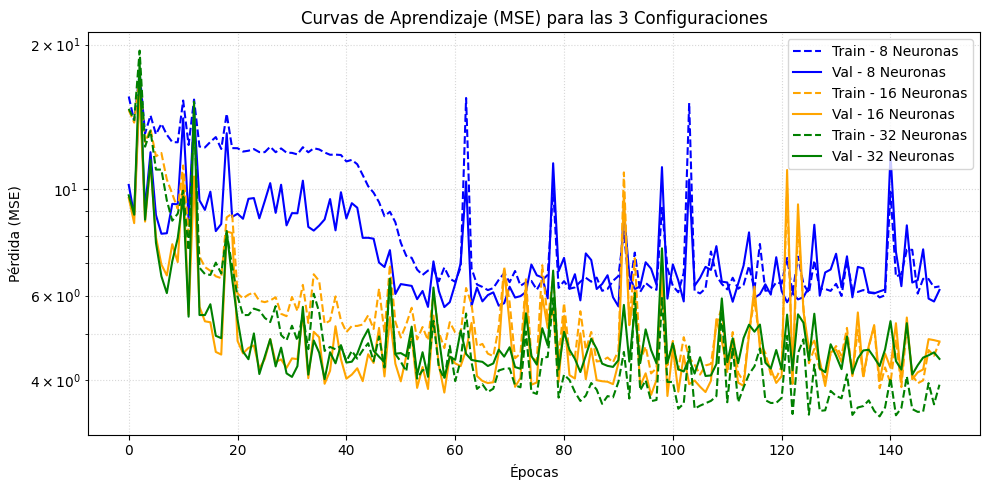

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(hist_A["train_loss"], label="Train - 8 Neuronas", linestyle="--", color="blue")
plt.plot(hist_A["val_loss"], label="Val - 8 Neuronas", color="blue")

plt.plot(hist_B["train_loss"], label="Train - 16 Neuronas", linestyle="--", color="orange")
plt.plot(hist_B["val_loss"], label="Val - 16 Neuronas", color="orange")

plt.plot(hist_C["train_loss"], label="Train - 32 Neuronas", linestyle="--", color="green")
plt.plot(hist_C["val_loss"], label="Val - 32 Neuronas", color="green")

plt.title("Curvas de Aprendizaje (MSE) para las 3 Configuraciones")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (MSE)")
plt.yscale("log") # Escala logarítmica para ver mejor los sutiles cambios al final
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

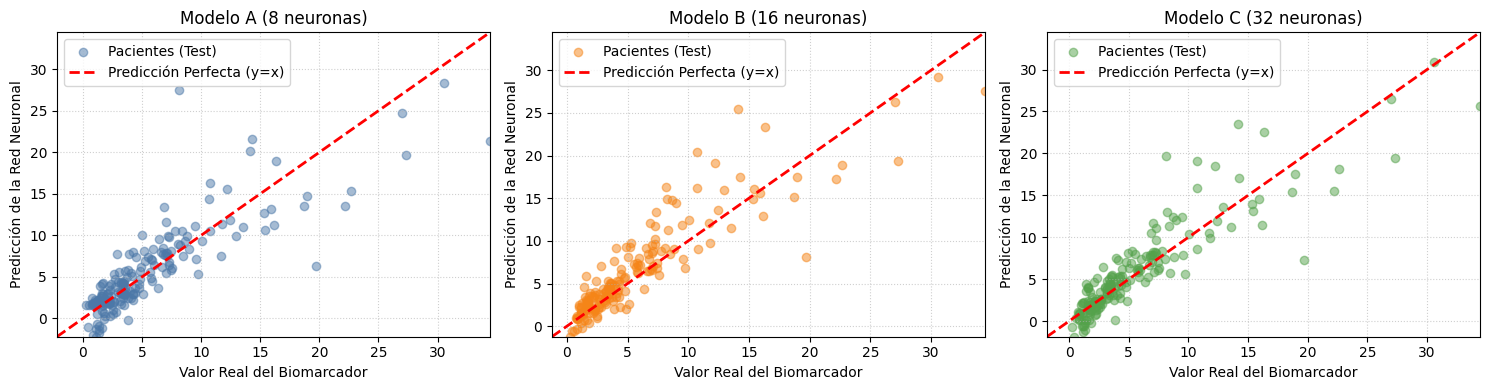

In [16]:
def graficar_prediccion_vs_real(y_real, y_pred, titulo, color_puntos):
    """
    Genera un scatter plot de los valores reales frente a las predicciones.
    """
    # Convertir a arreglos unidimensionales planos para matplotlib
    real_plano = y_real.flatten()
    pred_plano = y_pred.flatten()

    plt.scatter(real_plano, pred_plano, alpha=0.5, color=color_puntos, label="Pacientes (Test)")

    # Encontrar los valores mínimos y máximos globales para trazar una diagonal perfecta
    lim_min = min(real_plano.min(), pred_plano.min())
    lim_max = max(real_plano.max(), pred_plano.max())

    # Línea diagonal de referencia (Identidad: Predicción = Real)
    plt.plot([lim_min, lim_max], [lim_min, lim_max], color="red", linestyle="--", linewidth=2, label="Predicción Perfecta (y=x)")

    plt.title(titulo)
    plt.xlabel("Valor Real del Biomarcador")
    plt.ylabel("Predicción de la Red Neuronal")
    plt.xlim(lim_min, lim_max)
    plt.ylim(lim_min, lim_max)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()

# Generar una figura conjunta con subplots para los 3 modelos
fig_pred = plt.figure(figsize=(15, 4))

# Subplot 1: Modelo A (8 Neuronas)
plt.subplot(1, 3, 1)
y_pred_A, _ = forward_pass(X_test_scal, params_A)
graficar_prediccion_vs_real(y_test, y_pred_A, "Modelo A (8 neuronas)", "#4c78a8")

# Subplot 2: Modelo B (16 Neuronas)
plt.subplot(1, 3, 2)
y_pred_B, _ = forward_pass(X_test_scal, params_B)
graficar_prediccion_vs_real(y_test, y_pred_B, "Modelo B (16 neuronas)", "#f58518")

# Subplot 3: Modelo C (32 Neuronas)
plt.subplot(1, 3, 3)
y_pred_C, _ = forward_pass(X_test_scal, params_C)
graficar_prediccion_vs_real(y_test, y_pred_C, "Modelo C (32 neuronas)", "#54a24b")

plt.tight_layout()
plt.show()

## Sobre subajuste, sobreajuste y capacidad del modelo
1. Modelo A (8 Neuronas Ocultas)
- Capacidad del Modelo: Cuenta con 57 parámetros entrenables. Presenta subajuste. El número de parámetros restringe la complejidad de las funciones que la red puede aproximar, limitando la representación de la relación no lineal entre las características de entrada y la concentración del biomarcador. En las curvas de aprendizaje, tanto la pérdida de entrenamiento como la de validación convergen hacia valores estables que se mantienen altos en comparación con las otras configuraciones. En la gráfica de dispersión, esto se manifiesta en una mayor varianza de las predicciones en torno a la diagonal de referencia ($y=x$), observándose desviaciones en todo el rango de valores, particularmente en las magnitudes más altas del biomarcador.

2. Modelo B (16 Neuronas Ocultas)
- Capacidad del Modelo: Cuenta con 113 parámetros entrenables. Esta configuración equilibra la dimensión del espacio de parámetros con la complejidad del conjunto de datos. Las funciones de pérdida de entrenamiento y de validación disminuyen de forma paralela a lo largo de las épocas, manteniendo una diferencia mínima y estable entre sí. En la gráfica de dispersión, los puntos correspondientes a las predicciones del conjunto de prueba se distribuyen de manera concentrada y cercana a la línea de referencia ($y=x$), lo que se refleja cuantitativamente en una reducción del MAE y del RMSE en comparación con la configuración de 8 neuronas.

3. Modelo C (32 Neuronas Ocultas)
- Capacidad del Modelo: Cuenta con 225 parámetros entrenables. Presenta sobreajuste (overfitting). La cantidad de parámetros entrenables otorga al modelo una alta flexibilidad para ajustarse al conjunto de datos de entrenamiento. Como consecuencia, la pérdida de entrenamiento alcanza el valor numérico más bajo de los tres experimentos. Sin embargo, la pérdida de validación deja de disminuir, estabilizándose en un nivel superior o mostrando oscilaciones a partir de cierto número de épocas. En el conjunto de prueba, este comportamiento genera que las métricas globales de error (MAE y RMSE) no disminuyan significativamente en comparación con el modelo de 16 neuronas, lo que indica una pérdida en la capacidad de generalización del modelo ante datos no observados.

# Pytorch

Preparación

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Convertir arreglos de NumPy a Tensores de PyTorch (y transponer a formato estándar: Ejemplos x Features)
X_train_torch = torch.tensor(X_train_scal.T, dtype=torch.float32)
y_train_torch = torch.tensor(y_train.T, dtype=torch.float32)

X_val_torch = torch.tensor(X_val_scal.T, dtype=torch.float32)
y_val_torch = torch.tensor(y_val.T, dtype=torch.float32)

X_test_torch = torch.tensor(X_test_scal.T, dtype=torch.float32)
y_test_torch = torch.tensor(y_test.T, dtype=torch.float32)

# 2. Crear los DataLoaders (reemplazan por completo a nuestra función manual 'crear_minibatches')
dataset_entrenamiento = TensorDataset(X_train_torch, y_train_torch)
train_loader = DataLoader(dataset_entrenamiento, batch_size=32, shuffle=True)

Arquitectura

In [18]:
class RedBiomarcadorPyTorch(nn.Module):
    def __init__(self, n_entrada, n_ocultas, n_salida=1):
        super(RedBiomarcadorPyTorch, self).__init__()

        # Definición de capas
        self.capa_oculta = nn.Linear(n_entrada, n_ocultas)
        self.relu = nn.ReLU()
        self.capa_salida = nn.Linear(n_ocultas, n_salida)

        # Inicialización de He (Kaiming Normal) para mantener consistencia con NumPy
        nn.init.kaiming_normal_(self.capa_oculta.weight, nonlinearity='relu')
        nn.init.zeros_(self.capa_oculta.bias)

        # Inicialización Xavier/Linear para la salida
        nn.init.xavier_uniform_(self.capa_salida.weight)
        nn.init.zeros_(self.capa_salida.bias)

    def forward(self, x):
        # El camino hacia adelante (Forward Pass)
        x = self.capa_oculta(x)
        x = self.relu(x)
        x = self.capa_salida(x)
        return x

def obtener_parametros_entrenables(modelo):
    """Calcula automáticamente el total de parámetros tuning de la red."""
    return sum(p.numel() for p in modelo.parameters() if p.requires_grad)

Entrenamiento

In [19]:
def entrenar_red_pytorch(X_train, y_train, X_val, y_val, n_hidden, epocas, tamaño_batch, learning_rate, seed=42):
    """
    Bucle completo de entrenamiento utilizando PyTorch.
    """
    # Fijar la semilla de PyTorch para reproducibilidad
    torch.manual_seed(seed)

    n_entrada = X_train.shape[1] # Recuerda que en PyTorch es (ejemplos, features)

    # 1. Instanciar el modelo, la función de pérdida (criterio) y el optimizador (SGD)
    modelo = RedBiomarcadorPyTorch(n_entrada=n_entrada, n_ocultas=n_hidden)
    criterio = nn.MSELoss()
    optimizador = optim.SGD(modelo.parameters(), lr=learning_rate)

    # 2. Preparar el cargador de minibatches
    dataset_train = TensorDataset(X_train, y_train)
    train_loader = DataLoader(dataset_train, batch_size=tamaño_batch, shuffle=True)

    historial = {"train_loss": [], "val_loss": []}

    for epoca in range(1, epocas + 1):
        modelo.train() # Activar modo de entrenamiento
        loss_acumulada_train = 0.0

        for X_batch, y_batch in train_loader:
            # Paso A: Limpiar los gradientes calculados en el lote anterior
            optimizador.zero_grad()

            # Paso B: Forward Pass (propagación hacia adelante)
            predicciones = modelo(X_batch)

            # Paso C: Calcular el MSE del lote actual
            loss = criterio(predicciones, y_batch)

            # Paso D: Backpropagation automático (PyTorch calcula todos los gradientes)
            loss.backward()

            # Paso E: Actualizar pesos y sesgos (Descenso de Gradiente)
            optimizador.step()

            # Acumular la pérdida multiplicada por el tamaño del lote para ponderar correctamente
            loss_acumulada_train += loss.item() * X_batch.size(0)

        # Calcular pérdida promedio de entrenamiento de la época entera
        loss_train_epoca = loss_acumulada_train / X_train.size(0)

        # --- Fase de Validación (Evaluación global sin calcular gradientes) ---
        modelo.eval() # Activar modo de evaluación
        with torch.no_grad(): # Apagar el motor autograd para ahorrar memoria y tiempo
            predicciones_val = modelo(X_val)
            loss_val_epoca = criterio(predicciones_val, y_val).item()

        # Registrar el historial
        historial["train_loss"].append(loss_train_epoca)
        historial["val_loss"].append(loss_val_epoca)

        # Imprimir progreso cada 10 épocas
        if epoca % 10 == 0 or epoca == 1:
            print(f"Época {epoca}/{epocas} -> Pérdida Train: {loss_train_epoca:.4f} | Pérdida Val: {loss_val_epoca:.4f}")

    return modelo, historial

In [20]:
import time

EPOCAS = 150
TAMAÑO_BATCH = 32
TASA_APRENDIZAJE = 0.01

# --- Experimento A: 8 neuronas ---
print("--- Entrenando Configuración PyTorch A (8 neuronas) ---")
inicio_pt_A = time.time()
modelo_A_pt, hist_A_pt = entrenar_red_pytorch(
    X_train_torch, y_train_torch, X_val_torch, y_val_torch,
    n_hidden=8, epocas=EPOCAS, tamaño_batch=TAMAÑO_BATCH, learning_rate=TASA_APRENDIZAJE
)
tiempo_pt_A = time.time() - inicio_pt_A

# --- Experimento B: 16 neuronas ---
print("\n--- Entrenando Configuración PyTorch B (16 neuronas) ---")
inicio_pt_B = time.time()
modelo_B_pt, hist_B_pt = entrenar_red_pytorch(
    X_train_torch, y_train_torch, X_val_torch, y_val_torch,
    n_hidden=16, epocas=EPOCAS, tamaño_batch=TAMAÑO_BATCH, learning_rate=TASA_APRENDIZAJE
)
tiempo_pt_B = time.time() - inicio_pt_B

# --- Experimento C: 32 neuronas ---
print("\n--- Entrenando Configuración PyTorch C (32 neuronas) ---")
inicio_pt_C = time.time()
modelo_C_pt, hist_C_pt = entrenar_red_pytorch(
    X_train_torch, y_train_torch, X_val_torch, y_val_torch,
    n_hidden=32, epocas=EPOCAS, tamaño_batch=TAMAÑO_BATCH, learning_rate=TASA_APRENDIZAJE
)
tiempo_pt_C = time.time() - inicio_pt_C

--- Entrenando Configuración PyTorch A (8 neuronas) ---
Época 1/150 -> Pérdida Train: 46.1429 | Pérdida Val: 9.4486
Época 10/150 -> Pérdida Train: 8.5275 | Pérdida Val: 5.3503
Época 20/150 -> Pérdida Train: 6.8550 | Pérdida Val: 5.2424
Época 30/150 -> Pérdida Train: 6.1640 | Pérdida Val: 5.1763
Época 40/150 -> Pérdida Train: 5.4928 | Pérdida Val: 5.1475
Época 50/150 -> Pérdida Train: 5.1209 | Pérdida Val: 15.7833
Época 60/150 -> Pérdida Train: 4.8489 | Pérdida Val: 7.1685
Época 70/150 -> Pérdida Train: 4.6067 | Pérdida Val: 4.1399
Época 80/150 -> Pérdida Train: 4.5372 | Pérdida Val: 4.0958
Época 90/150 -> Pérdida Train: 4.4890 | Pérdida Val: 6.2836
Época 100/150 -> Pérdida Train: 4.4023 | Pérdida Val: 5.3835
Época 110/150 -> Pérdida Train: 4.6150 | Pérdida Val: 3.9427
Época 120/150 -> Pérdida Train: 4.3646 | Pérdida Val: 4.1511
Época 130/150 -> Pérdida Train: 4.3468 | Pérdida Val: 4.0018
Época 140/150 -> Pérdida Train: 4.5269 | Pérdida Val: 5.8705
Época 150/150 -> Pérdida Train: 4.1506

Métricas

In [21]:
resultados_tabla_pt = {}

# Mapeo de cada modelo con su respectivo tiempo registrado
configuraciones_pt = [
    ("Modelo A (8 neuronas)", modelo_A_pt, tiempo_pt_A),
    ("Modelo B (16 neuronas)", modelo_B_pt, tiempo_pt_B),
    ("Modelo C (32 neuronas)", modelo_C_pt, tiempo_pt_C)
]

for nombre, modelo, tiempo_ejecucion in configuraciones_pt:

    # 1. Configurar modelo en modo de evaluación
    modelo.eval()
    with torch.no_grad():
        # Obtener la predicción directa del modelo de regresión estándar
        predicciones_test = modelo(X_test_torch)
        # Convertir a numpy y transponer al formato original de evaluación (1, m)
        y_pred_test = predicciones_test.numpy().T

    # 2. Calcular métricas utilizando la función definida en la Sección 1
    mae_t, rmse_t, mre_t = calcular_metricas(y_test, y_pred_test)

    # 3. Calcular el número total de parámetros entrenables en PyTorch
    total_parametros = sum(p.numel() for p in modelo.parameters() if p.requires_grad)

    # Guardar registros en el diccionario
    resultados_tabla_pt[nombre] = {
        "Parámetros": total_parametros,
        "Tiempo (s)": tiempo_ejecucion,
        "MAE": mae_t,
        "RMSE": rmse_t,
        "Error Relativo (%)": mre_t
    }

# --- Imprimir la tabla de resultados de PyTorch ---
print("\n" + "="*91)
print(f"{'CONFIGURACIÓN PYTORCH':<25} | {'PARÁMETROS':<10} | {'TIEMPO (s)':<10} | {'MAE':<8} | {'RMSE':<8} | {'ERR. RELATIVO (%)':<15}")
print("="*91)
for modelo, metricas in resultados_tabla_pt.items():
    print(f"{modelo:<25} | {metricas['Parámetros']:<10} | {metricas['Tiempo (s)']:<10.2f} | {metricas['MAE']:<8.4f} | {metricas['RMSE']:<8.4f} | {metricas['Error Relativo (%)']:<15.2f}%")
print("="*91)


CONFIGURACIÓN PYTORCH     | PARÁMETROS | TIEMPO (s) | MAE      | RMSE     | ERR. RELATIVO (%)
Modelo A (8 neuronas)     | 57         | 12.93      | 2.1866   | 3.1512   | 63.10          %
Modelo B (16 neuronas)    | 113        | 11.54      | 1.5764   | 2.4688   | 40.79          %
Modelo C (32 neuronas)    | 225        | 5.74       | 1.8313   | 2.8839   | 52.40          %


Gráficas

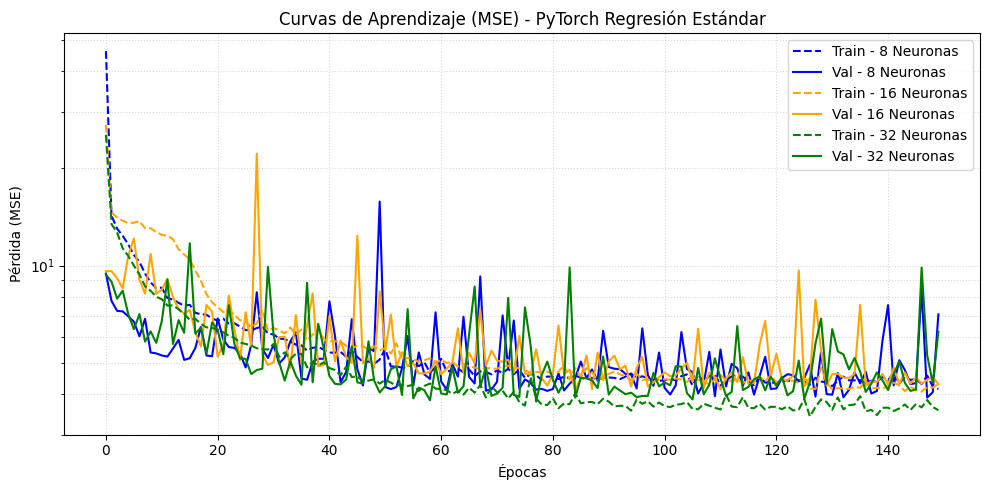

In [22]:
plt.figure(figsize=(10, 5))

# Configuración A (8 Neuronas)
plt.plot(hist_A_pt["train_loss"], label="Train - 8 Neuronas", linestyle="--", color="blue")
plt.plot(hist_A_pt["val_loss"], label="Val - 8 Neuronas", color="blue")

# Configuración B (16 Neuronas)
plt.plot(hist_B_pt["train_loss"], label="Train - 16 Neuronas", linestyle="--", color="orange")
plt.plot(hist_B_pt["val_loss"], label="Val - 16 Neuronas", color="orange")

# Configuración C (32 Neuronas)
plt.plot(hist_C_pt["train_loss"], label="Train - 32 Neuronas", linestyle="--", color="green")
plt.plot(hist_C_pt["val_loss"], label="Val - 32 Neuronas", color="green")

plt.title("Curvas de Aprendizaje (MSE) - PyTorch Regresión Estándar")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (MSE)")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

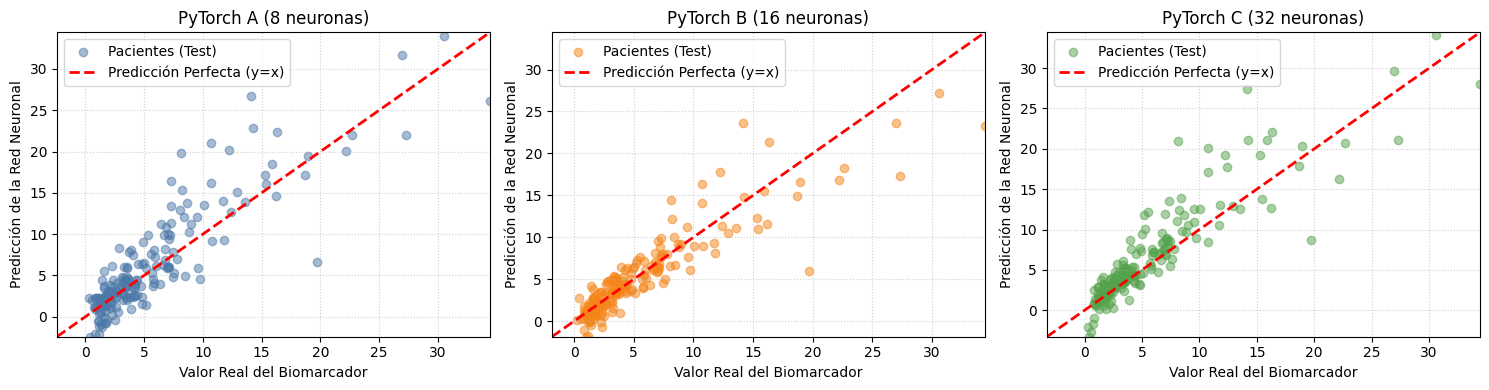

In [23]:
def graficar_prediccion_vs_real_pt(y_real, y_pred, titulo, color_puntos):
    """
    Genera un scatter plot de los valores reales frente a las predicciones en PyTorch.
    """
    real_plano = y_real.flatten()
    pred_plano = y_pred.flatten()

    plt.scatter(real_plano, pred_plano, alpha=0.5, color=color_puntos, label="Pacientes (Test)")

    # Límites dinámicos basados en los valores mínimos y máximos observados
    lim_min = min(real_plano.min(), pred_plano.min())
    lim_max = max(real_plano.max(), pred_plano.max())

    # Diagonal de referencia de predicción perfecta
    plt.plot([lim_min, lim_max], [lim_min, lim_max], color="red", linestyle="--", linewidth=2, label="Predicción Perfecta (y=x)")

    plt.title(titulo)
    plt.xlabel("Valor Real del Biomarcador")
    plt.ylabel("Predicción de la Red Neuronal")
    plt.xlim(lim_min, lim_max)
    plt.ylim(lim_min, lim_max)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()

# 1. Configurar los modelos en modo de evaluación y extraer predicciones en formato NumPy
modelo_A_pt.eval()
modelo_B_pt.eval()
modelo_C_pt.eval()

with torch.no_grad():
    y_pred_A_pt = modelo_A_pt(X_test_torch).numpy().T
    y_pred_B_pt = modelo_B_pt(X_test_torch).numpy().T
    y_pred_C_pt = modelo_C_pt(X_test_torch).numpy().T

# 2. Construcción de la figura con subplots
fig_pred_pt = plt.figure(figsize=(15, 4))

# Subplot Modelo A
plt.subplot(1, 3, 1)
graficar_prediccion_vs_real_pt(y_test, y_pred_A_pt, "PyTorch A (8 neuronas)", "#4c78a8")

# Subplot Modelo B
plt.subplot(1, 3, 2)
graficar_prediccion_vs_real_pt(y_test, y_pred_B_pt, "PyTorch B (16 neuronas)", "#f58518")

# Subplot Modelo C
plt.subplot(1, 3, 3)
graficar_prediccion_vs_real_pt(y_test, y_pred_C_pt, "PyTorch C (32 neuronas)", "#54a24b")

plt.tight_layout()
plt.show()

##  Pytorch vs Implementación sin librería

* **Desempeño predictivo en el conjunto de prueba:** **Equivalente.** Ambos modelos convergen a métricas globales similares (MAE y RMSE), ya que resuelven la misma aproximación matemática subyacente sobre el mismo dataset.
* **Velocidad de entrenamiento:** **Desde cero es más rápido.** Al procesar una red pequeña con pocos datos, NumPy opera directamente en memoria contigua sin el costo computacional que introduce PyTorch.
* **Estabilidad de la optimización:** **PyTorch es más estable.** Presenta curvas de pérdida con un descenso más suavizado y menor fluctuación entre épocas consecutivas en la fase final de convergencia.
* **Sensibilidad a la tasa de aprendizaje ($\eta$):** **Desde cero es altamente sensible.** Al usar un SGD básico fijo, cambios en el orden de magnitud de $\eta$ provocan o estancamiento inmediato o divergencia matemática. **PyTorch exhibe sensibilidad moderada**.
* **Facilidad para cambiar arquitectura, pérdida y regularización:** **PyTorch es superior.** Su diseño modular (`nn.Module`, `nn.Sequential`) permite modificar componentes en una línea. **Desde cero tiene flexibilidad baja**, pues cualquier cambio exige recalcular a mano las derivadas del backpropagation y reescribir las operaciones matriciales.


* **Inicialización:** Desde cero utiliza un escalamiento normal o uniforme arbitrario manual. PyTorch implementa algoritmos de preservación de varianza (**He/Kaiming** o **Xavier/Glorot**), optimizando el punto de partida en el espacio de pérdida.
* **Optimizadores:** Desde cero se limita a SGD clásico, donde la actualización es puramente lineal respecto al gradiente actual ($\Delta W = -\eta \cdot \nabla W$). PyTorch permite alternar a algoritmos basados en momentos o tasas adaptativas (**Adam**), que amortiguan y dirigen la trayectoria.
* **Precisión numérica:** NumPy opera por defecto con `float64` (doble precisión, menor error de truncamiento analítico). PyTorch entrena por defecto en `float32` (precisión simple, diseñado para economizar memoria y acelerar el cómputo sin degradar la regresión).
* **Tamaño de minibatch y manejo de datos:** NumPy requiere indexación matricial manual y secuencial (`X[:, i:i+batch_size]`). PyTorch delega esto en `TensorDataset` y `DataLoader`.
* **Criterios de parada:** Desde cero se ejecuta de forma estática durante el número fijo de épocas programadas. PyTorch facilita el monitoreo de la pérdida de validación en tiempo real para activar **Early Stopping** y evitar el sobreajuste.
* **Cálculo de gradiente:** Desde cero se basa en la codificación explícita de las matrices traspuestas de la regla de la cadena, siendo rígido ante cambios estructurales. PyTorch utiliza **Autograd**, construyendo un grafo acíclico dirigido en el *forward pass* para ejecutar diferenciación automática analítica exacta.

# Verosimilitud para una variable objetivo positiva

Derivación. Se eligió Log-normal:

- La concentración del biomarcador es una variable continua y estrictamente positiva ($y_i > 0$). La distribución Log-Normal modela variables cuyo logaritmo sigue una distribución normal, lo que se adapta de forma natural a datos con asimetría positiva y soporte acotado en el cero

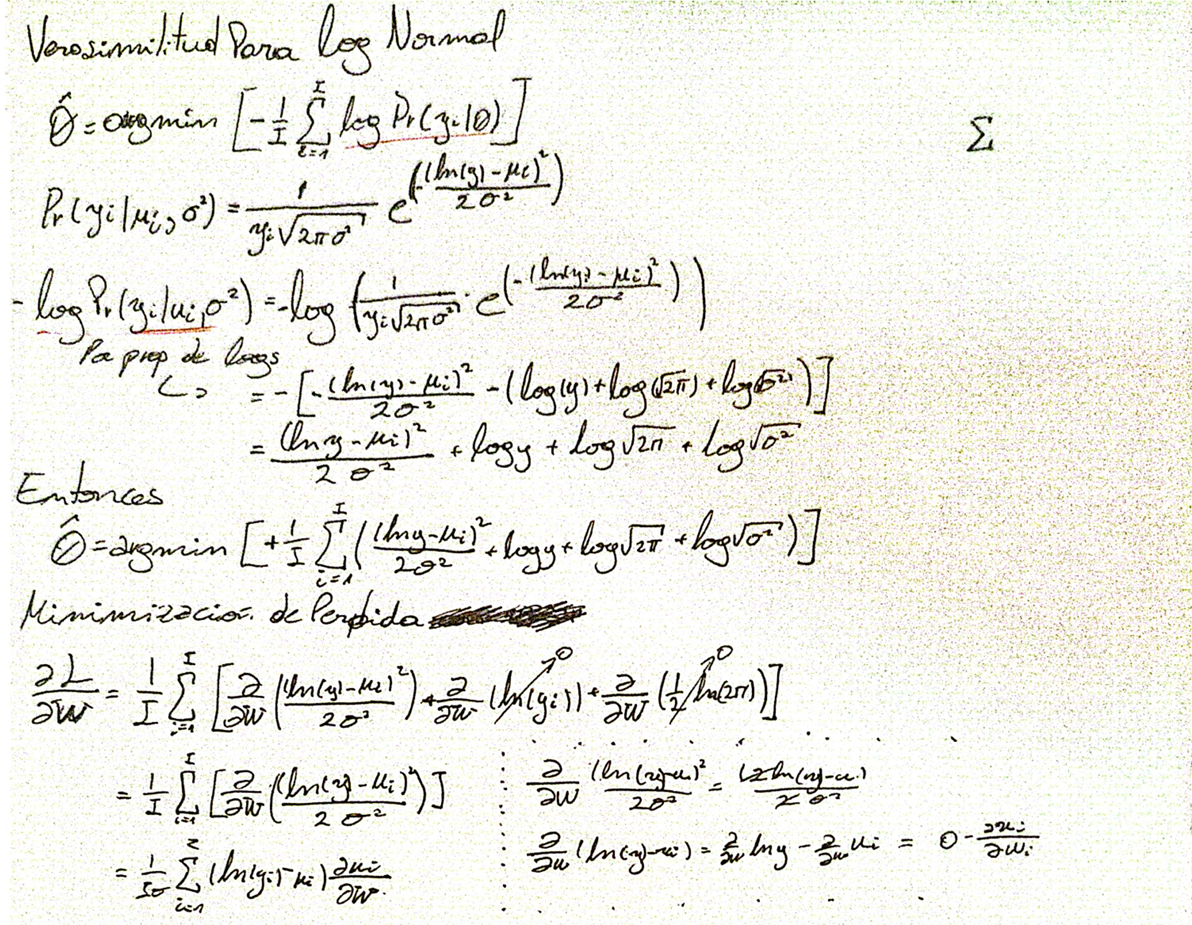

> Disculpar la resolución

La red neuronal predice directamente el parámetro de localización $\mu_i$, el cual representa el valor esperado del logaritmo de la concentración del biomarcador. El dominio del parámetro $\mu_i$ pertenece al conjunto de los números reales ($\mathbb{R}$). Por lo tanto, la capa de salida de la red neuronal utiliza una activación lineal (sin restricciones matemáticas en la última capa).

Para regresar al dominio biológico original del biomarcador durante la inferencia o evaluación, se aplica la función exponencial a la salida de la red: $y_{\text{pred}} = \exp(\mu_i)$. Debido a que $e^{\mu_i} > 0$ para cualquier $\mu_i \in \mathbb{R}$, se garantiza matemáticamente que la predicción final jamás adoptará valores negativos o iguales a cero.

Modelo log-normal

In [24]:
class RedBiomarcadorLogNormal(nn.Module):
    def __init__(self, n_entrada, n_ocultas, n_salida=1):
        super(RedBiomarcadorLogNormal, self).__init__()
        self.capa_oculta = nn.Linear(n_entrada, n_ocultas)
        self.relu = nn.ReLU()
        self.capa_salida = nn.Linear(n_ocultas, n_salida) # Salida lineal (parámetro mu)

        # Inicialización de pesos He (Kaiming) para la capa oculta
        nn.init.kaiming_normal_(self.capa_oculta.weight, nonlinearity='relu')
        nn.init.zeros_(self.capa_oculta.bias)

        # Inicialización Xavier para la capa de salida
        nn.init.xavier_uniform_(self.capa_salida.weight)
        nn.init.zeros_(self.capa_salida.bias)

    def forward(self, x):
        x = self.capa_oculta(x)
        x = self.relu(x)
        x = self.capa_salida(x)
        return x

def perdida_nll_lognormal(mu_predicha, y_real):
    """
    Implementa la pérdida derivada por Máxima Verosimilitud.
    Calcula el MSE entre el logit latente 'mu' y el logaritmo natural del target real.
    """
    log_y_real = torch.log(y_real)
    return torch.mean((mu_predicha - log_y_real) ** 2)


def entrenar_pytorch_lognormal(n_hidden, epocas=150, learning_rate=0.01):
    torch.manual_seed(42)
    modelo = RedBiomarcadorLogNormal(n_entrada=5, n_ocultas=n_hidden)
    optimizador = optim.SGD(modelo.parameters(), lr=learning_rate)

    historial = {"train_loss": [], "val_loss": []}

    for epoca in range(1, epocas + 1):
        modelo.train()
        loss_acumulada_train = 0.0

        # Aquí es donde se definen correctamente X_batch e y_batch en cada lote
        for X_batch, y_batch in train_loader:
            optimizador.zero_grad()
            mu_predicha = modelo(X_batch)
            loss = perdida_nll_lognormal(mu_predicha, y_batch)
            loss.backward()
            optimizador.step()

            loss_acumulada_train += loss.item() * X_batch.size(0)

        loss_train_epoca = loss_acumulada_train / X_train_torch.size(0)

        # Fase de Validación global
        modelo.eval()
        with torch.no_grad():
            mu_val = modelo(X_val_torch)
            loss_val_epoca = perdida_nll_lognormal(mu_val, y_val_torch).item()

        historial["train_loss"].append(loss_train_epoca)
        historial["val_loss"].append(loss_val_epoca)

        if epoca % 20 == 0 or epoca == 1:
            print(f"Época {epoca:03d}/{epocas} -> NLL Train: {loss_train_epoca:.4f} | NLL Val: {loss_val_epoca:.4f}")

    return modelo, historial


inicio = time.time()
print("Iniciando entrenamiento en PyTorch con Soporte Positivo...")
modelo_optimizado, historial_nll = entrenar_pytorch_lognormal(n_hidden=16)
tiempo = time.time() - inicio
print(f"Tiempo de entrenamiento finalizado: {tiempo:.2f} segundos")

Iniciando entrenamiento en PyTorch con Soporte Positivo...
Época 001/150 -> NLL Train: 1.5955 | NLL Val: 0.5574
Época 020/150 -> NLL Train: 0.2332 | NLL Val: 0.2047
Época 040/150 -> NLL Train: 0.1586 | NLL Val: 0.1501
Época 060/150 -> NLL Train: 0.0951 | NLL Val: 0.1002
Época 080/150 -> NLL Train: 0.0708 | NLL Val: 0.0809
Época 100/150 -> NLL Train: 0.0660 | NLL Val: 0.0780
Época 120/150 -> NLL Train: 0.0641 | NLL Val: 0.0766
Época 140/150 -> NLL Train: 0.0625 | NLL Val: 0.0759
Tiempo de entrenamiento finalizado: 3.63 segundos


In [25]:
# 5. EVALUACIÓN Y RETORNO AL DOMINIO ORIGINAL
modelo_optimizado.eval()
with torch.no_grad():
    # Obtener el parámetro mu predicho para el conjunto de test
    mu_test = modelo_optimizado(X_test_torch)

    # ¡Aplicamos el exponencial para garantizar soporte estrictamente positivo!
    y_pred_test_positivo = torch.exp(mu_test).numpy().T

# Calcular métricas usando la función que definiste en la sección 1
mae_pt, rmse_pt, mre_pt = calcular_metricas(y_test, y_pred_test_positivo)

print("\n--- RENDIMIENTO DEL MODELO LOG-NORMAL EN TEST ---")
print(f"MAE: {mae_pt:.4f}")
print(f"RMSE: {rmse_pt:.4f}")
print(f"Error Relativo Medio: {mre_pt:.2f}%")


--- RENDIMIENTO DEL MODELO LOG-NORMAL EN TEST ---
MAE: 1.3923
RMSE: 2.4762
Error Relativo Medio: 24.30%


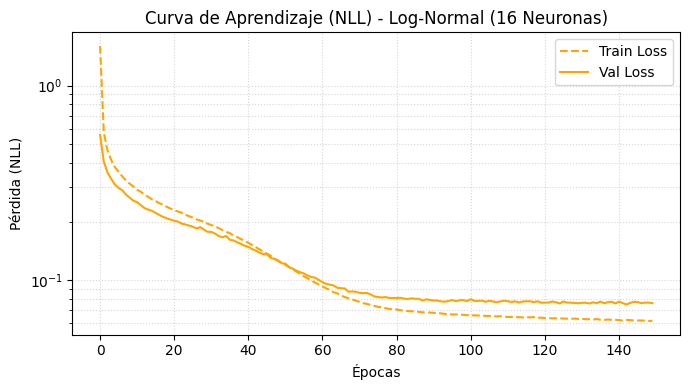

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(historial_nll["train_loss"], label="Train Loss", linestyle="--", color="orange")
plt.plot(historial_nll["val_loss"], label="Val Loss", color="orange")

plt.title("Curva de Aprendizaje (NLL) - Log-Normal (16 Neuronas)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (NLL)")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

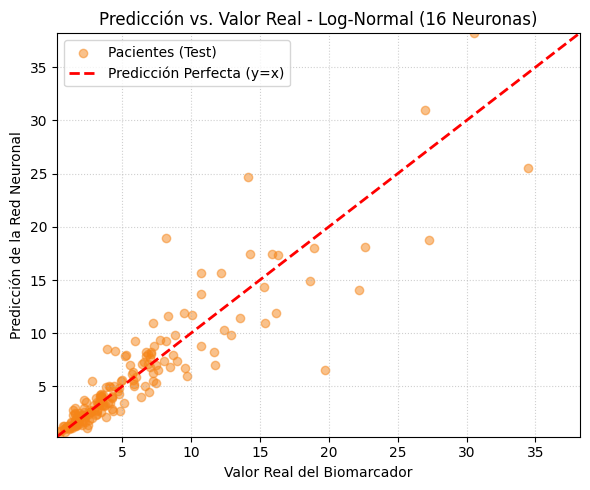

In [27]:
modelo_optimizado.eval()
with torch.no_grad():
    y_pred_nll = torch.exp(modelo_optimizado(X_test_torch)).numpy().T

# 2. Generar el gráfico de dispersión frente a la diagonal y=x
plt.figure(figsize=(6, 5))
real_plano = y_test.flatten()
pred_plano = y_pred_nll.flatten()

plt.scatter(real_plano, pred_plano, alpha=0.5, color="#f58518", label="Pacientes (Test)")

# Límites para una diagonal perfecta
lim_min = min(real_plano.min(), pred_plano.min())
lim_max = max(real_plano.max(), pred_plano.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], color="red", linestyle="--", linewidth=2, label="Predicción Perfecta (y=x)")

plt.title("Predicción vs. Valor Real - Log-Normal (16 Neuronas)")
plt.xlabel("Valor Real del Biomarcador")
plt.ylabel("Predicción de la Red Neuronal")
plt.xlim(lim_min, lim_max)
plt.ylim(lim_min, lim_max)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Regularización

Dropout: La desactivación estocástica del 20% de las neuronas ocultas impedirá la coadaptación de los pesos. Se espera que la pérdida de entrenamiento descienda a una velocidad menor en comparación con el modelo base. La brecha (gap) entre la pérdida de entrenamiento y la de validación se reducirá de manera significativa, estabilizando el error de validación en épocas tardías, aunque sin detener el entrenamiento si este se estanca.

In [28]:
class RedDropout(nn.Module):
    def __init__(self, n_entrada, n_ocultas, p_dropout=0.2):
        super(RedDropout, self).__init__()
        self.capa_oculta = nn.Linear(n_entrada, n_ocultas)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=p_dropout) # Solo Dropout
        self.capa_salida = nn.Linear(n_ocultas, 1)

        nn.init.kaiming_normal_(self.capa_oculta.weight, nonlinearity='relu')
        nn.init.zeros_(self.capa_oculta.bias)
        nn.init.xavier_uniform_(self.capa_salida.weight)
        nn.init.zeros_(self.capa_salida.bias)

    def forward(self, x):
        x = self.capa_oculta(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.capa_salida(x)
        return x

def entrenar_dropout(n_hidden, epocas=300, learning_rate=0.01, p_dropout=0.2):
    torch.manual_seed(42)
    modelo = RedDropout(n_entrada=5, n_ocultas=n_hidden, p_dropout=p_dropout)
    optimizador = optim.SGD(modelo.parameters(), lr=learning_rate) # SGD estándar

    historial = {"train_loss": [], "val_loss": []}

    for epoca in range(1, epocas + 1):
        modelo.train()
        loss_acumulada_train = 0.0
        for X_batch, y_batch in train_loader:
            optimizador.zero_grad()
            mu_predicha = modelo(X_batch)
            loss = perdida_nll_lognormal(mu_predicha, y_batch)
            loss.backward()
            optimizador.step()
            loss_acumulada_train += loss.item() * X_batch.size(0)

        loss_train_epoca = loss_acumulada_train / X_train_torch.size(0)

        modelo.eval()
        with torch.no_grad():
            mu_val = modelo(X_val_torch)
            loss_val_epoca = perdida_nll_lognormal(mu_val, y_val_torch).item()

        historial["train_loss"].append(loss_train_epoca)
        historial["val_loss"].append(loss_val_epoca)

    return modelo, historial

$L_2$: La penalización cuadrática limitará el crecimiento de la magnitud de las matrices de pesos, forzando una distribución de parámetros con valores pequeños. Dado que los sesgos quedan excluidos de la penalización, el modelo preservará su flexibilidad para desplazar la función de activación sin introducir distorsiones (underfitting por sesgo rígido). El error de entrenamiento no alcanzará valores cercanos a cero, pero la curva de validación se mantendrá asintótica y estable sin mostrar divergencias.

In [29]:
class RedBase(nn.Module): # Arquitectura limpia sin Dropout
    def __init__(self, n_entrada, n_ocultas):
        super(RedBase, self).__init__()
        self.capa_oculta = nn.Linear(n_entrada, n_ocultas)
        self.relu = nn.ReLU()
        self.capa_salida = nn.Linear(n_ocultas, 1)

        nn.init.kaiming_normal_(self.capa_oculta.weight, nonlinearity='relu')
        nn.init.zeros_(self.capa_oculta.bias)
        nn.init.xavier_uniform_(self.capa_salida.weight)
        nn.init.zeros_(self.capa_salida.bias)

    def forward(self, x):
        x = self.capa_oculta(x)
        x = self.relu(x)
        x = self.capa_salida(x)
        return x

def entrenar_l2_solo_pesos(n_hidden, epocas=300, learning_rate=0.01, weight_decay=1e-4):
    torch.manual_seed(42)
    modelo = RedBase(n_entrada=5, n_ocultas=n_hidden)

    # Filtrado selectivo para excluir los sesgos (biases)
    pesos = [p for n, p in modelo.named_parameters() if 'bias' not in n]
    sesgos = [p for n, p in modelo.named_parameters() if 'bias' in n]

    optimizador = optim.SGD([
        {'params': pesos, 'weight_decay': weight_decay},
        {'params': sesgos, 'weight_decay': 0.0}
    ], lr=learning_rate)

    historial = {"train_loss": [], "val_loss": []}

    for epoca in range(1, epocas + 1):
        modelo.train()
        loss_acumulada_train = 0.0
        for X_batch, y_batch in train_loader:
            optimizador.zero_grad()
            mu_predicha = modelo(X_batch)
            loss = perdida_nll_lognormal(mu_predicha, y_batch)
            loss.backward()
            optimizador.step()
            loss_acumulada_train += loss.item() * X_batch.size(0)

        loss_train_epoca = loss_acumulada_train / X_train_torch.size(0)

        modelo.eval()
        with torch.no_grad():
            mu_val = modelo(X_val_torch)
            loss_val_epoca = perdida_nll_lognormal(mu_val, y_val_torch).item()

        historial["train_loss"].append(loss_train_epoca)
        historial["val_loss"].append(loss_val_epoca)

    return modelo, historial

$L_1$: La penalización del valor absoluto inducirá dispersión en las matrices de pesos, guiando los parámetros menos relevantes hacia cero. Esto funciona como un mecanismo de selección de características de entrada. Las curvas de aprendizaje pueden manifestar pequeñas oscilaciones numéricas debido a la discontinuidad de la derivada de la función valor absoluto en cero, pero controlarán el sobreajuste al simplificar la red.

In [30]:
def entrenar_l1_solo_pesos(n_hidden, epocas=300, learning_rate=0.01, l1_lambda=1e-4):
    torch.manual_seed(42)
    modelo = RedBase(n_entrada=5, n_ocultas=n_hidden)
    optimizador = optim.SGD(modelo.parameters(), lr=learning_rate)

    historial = {"train_loss": [], "val_loss": []}

    for epoca in range(1, epocas + 1):
        modelo.train()
        loss_acumulada_train = 0.0
        for X_batch, y_batch in train_loader:
            optimizador.zero_grad()
            mu_predicha = modelo(X_batch)

            loss_base = perdida_nll_lognormal(mu_predicha, y_batch)

            # Penalización L1 calculada estrictamente sobre las matrices de pesos
            l1_penalty = sum(p.abs().sum() for name, p in modelo.named_parameters() if 'weight' in name)

            loss_total = loss_base + (l1_lambda * l1_penalty)

            loss_total.backward()
            optimizador.step()
            loss_acumulada_train += loss_base.item() * X_batch.size(0)

        loss_train_epoca = loss_acumulada_train / X_train_torch.size(0)

        modelo.eval()
        with torch.no_grad():
            mu_val = modelo(X_val_torch)
            loss_val_epoca = perdida_nll_lognormal(mu_val, y_val_torch).item()

        historial["train_loss"].append(loss_train_epoca)
        historial["val_loss"].append(loss_val_epoca)

    return modelo, historial

Early Stopping:  Este mecanismo no altera la función de pérdida ni restringe los pesos durante el cómputo, por lo que la red mantendrá su velocidad de aprendizaje inicial. La detención se activará de en el momento en que la curva de validación cese su tendencia decreciente y comience a estancarse o subir, truncando el proceso antes de que el modelo asimile el ruido estocástico del conjunto de entrenamiento y garantizando la máxima capacidad de generalización obtenible con la arquitectura base.

In [31]:
def entrenar_early_stopping(n_hidden, epocas=300, learning_rate=0.01, patience=25):
    torch.manual_seed(42)
    modelo = RedBase(n_entrada=5, n_ocultas=n_hidden)
    optimizador = optim.SGD(modelo.parameters(), lr=learning_rate)

    historial = {"train_loss": [], "val_loss": []}

    mejor_loss_val = float('inf')
    epochs_sin_mejorar = 0
    mejores_parametros = None
    epoca_detencion = epocas

    for epoca in range(1, epocas + 1):
        modelo.train()
        loss_acumulada_train = 0.0
        for X_batch, y_batch in train_loader:
            optimizador.zero_grad()
            mu_predicha = modelo(X_batch)
            loss = perdida_nll_lognormal(mu_predicha, y_batch)
            loss.backward()
            optimizador.step()
            loss_acumulada_train += loss.item() * X_batch.size(0)

        loss_train_epoca = loss_acumulada_train / X_train_torch.size(0)

        modelo.eval()
        with torch.no_grad():
            mu_val = modelo(X_val_torch)
            loss_val_epoca = perdida_nll_lognormal(mu_val, y_val_torch).item()

        historial["train_loss"].append(loss_train_epoca)
        historial["val_loss"].append(loss_val_epoca)

        # Monitoreo de Early Stopping
        if loss_val_epoca < mejor_loss_val:
            mejor_loss_val = loss_val_epoca
            epochs_sin_mejorar = 0
            mejores_parametros = copy.deepcopy(modelo.state_dict())
        else:
            epochs_sin_mejorar += 1

        if epochs_sin_mejorar >= patience:
            epoca_detencion = epoca
            print(f"\n[Early Stopping] Detenido en la época {epoca}. Restaurando mejores pesos.")
            modelo.load_state_dict(mejores_parametros)
            break

    return modelo, historial, epoca_detencion

In [32]:
def evaluar_y_graficar(modelo, historial, tiempo_ejecucion, titulo, color_puntos):
    """
    Calcula métricas exponenciales en Test y genera gráficos de Pérdida y Dispersión.
    """
    # 1. Inferencia en el conjunto de prueba y retorno al dominio original
    modelo.eval()
    with torch.no_grad():
        y_pred_test_positivo = torch.exp(modelo(X_test_torch)).numpy().T

    # 2. Calcular métricas utilizando tu función de la Sección 1
    mae_t, rmse_t, mre_t = calcular_metricas(y_test, y_pred_test_positivo)
    total_parametros = sum(p.numel() for p in modelo.parameters() if p.requires_grad)

    # 3. Imprimir reporte de métricas en consola
    print(f"\n" + "="*50)
    print(f"REPORTE: {titulo.upper()}")
    print("="*50)
    print(f"Parámetros Entrenables: {total_parametros}")
    print(f"Tiempo de Entrenamiento: {tiempo_ejecucion:.2f} segundos")
    print(f"MAE:  {mae_t:.4f}")
    print(f"RMSE: {rmse_t:.4f}")
    print(f"Error Relativo Medio: {mre_t:.2f}%")
    print("="*50)

    # 4. Generación de Gráficos Distribuidos
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    # Gráfico A: Curvas de Aprendizaje
    ax1.plot(historial["train_loss"], label="Train Loss", linestyle="--", color=color_puntos)
    ax1.plot(historial["val_loss"], label="Val Loss", color=color_puntos)
    ax1.set_title(f"Curva de Aprendizaje - {titulo}")
    ax1.set_xlabel("Épocas")
    ax1.set_ylabel("Pérdida (NLL)")
    ax1.set_yscale("log")
    ax1.legend()
    ax1.grid(True, which="both", linestyle=":", alpha=0.5)

    # Gráfico B: Predicho vs Valor Real
    real_plano = y_test.flatten()
    pred_plano = y_pred_test_positivo.flatten()
    ax2.scatter(real_plano, pred_plano, alpha=0.5, color=color_puntos, label="Pacientes (Test)")

    lim_min = min(real_plano.min(), pred_plano.min())
    lim_max = max(real_plano.max(), pred_plano.max())
    ax2.plot([lim_min, lim_max], [lim_min, lim_max], color="red", linestyle="--", linewidth=2, label="y=x")

    ax2.set_title(f"Predicho vs Real - {titulo}")
    ax2.set_xlabel("Valor Real")
    ax2.set_ylabel("Predicción")
    ax2.set_xlim(lim_min, lim_max)
    ax2.set_ylim(lim_min, lim_max)
    ax2.legend()
    ax2.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()


REPORTE: DROPOUT EXCLUSIVO (P=0.2)
Parámetros Entrenables: 113
Tiempo de Entrenamiento: 8.77 segundos
MAE:  1.5130
RMSE: 2.9737
Error Relativo Medio: 27.24%


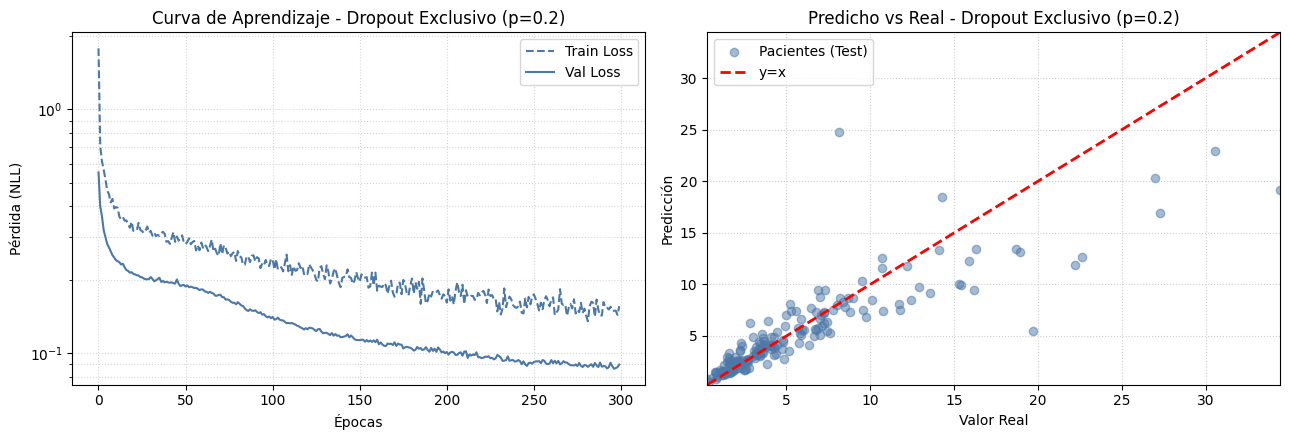

In [33]:
inicio = time.time()
modelo_dropout, hist_dropout = entrenar_dropout(n_hidden=16)
tiempo = time.time() - inicio

evaluar_y_graficar(modelo_dropout, hist_dropout, tiempo, "Dropout Exclusivo (p=0.2)", "#4c78a8")


REPORTE: REGULARIZACIÓN L2 (SOLO PESOS)
Parámetros Entrenables: 113
Tiempo de Entrenamiento: 7.62 segundos
MAE:  1.3337
RMSE: 2.4035
Error Relativo Medio: 23.83%


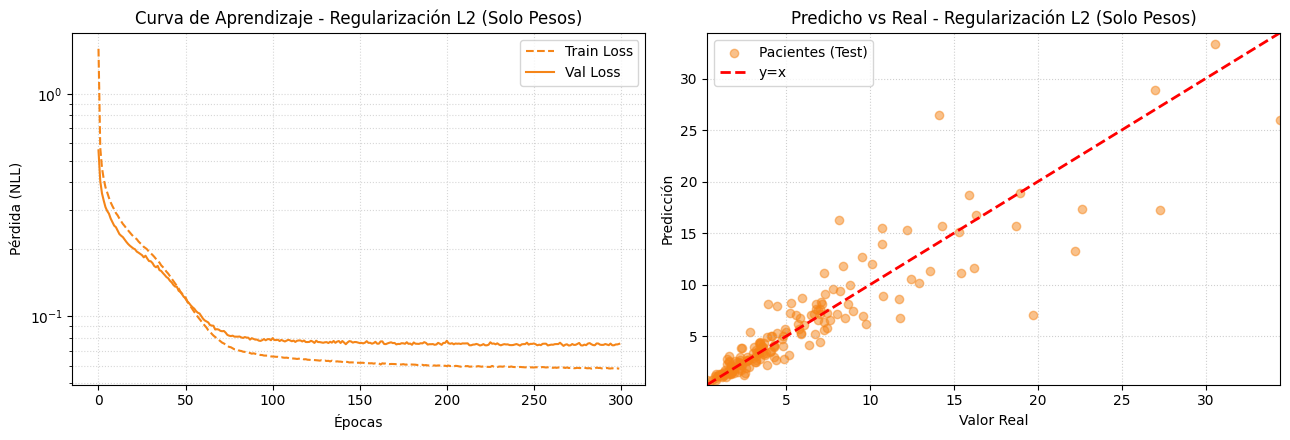

In [34]:
inicio = time.time()
modelo_l2, hist_l2 = entrenar_l2_solo_pesos(n_hidden=16)
tiempo = time.time() - inicio

evaluar_y_graficar(modelo_l2, hist_l2, tiempo, "Regularización L2 (Solo Pesos)", "#f58518")


REPORTE: REGULARIZACIÓN L1 (SOLO PESOS)
Parámetros Entrenables: 113
Tiempo de Entrenamiento: 9.74 segundos
MAE:  1.3321
RMSE: 2.4032
Error Relativo Medio: 23.80%


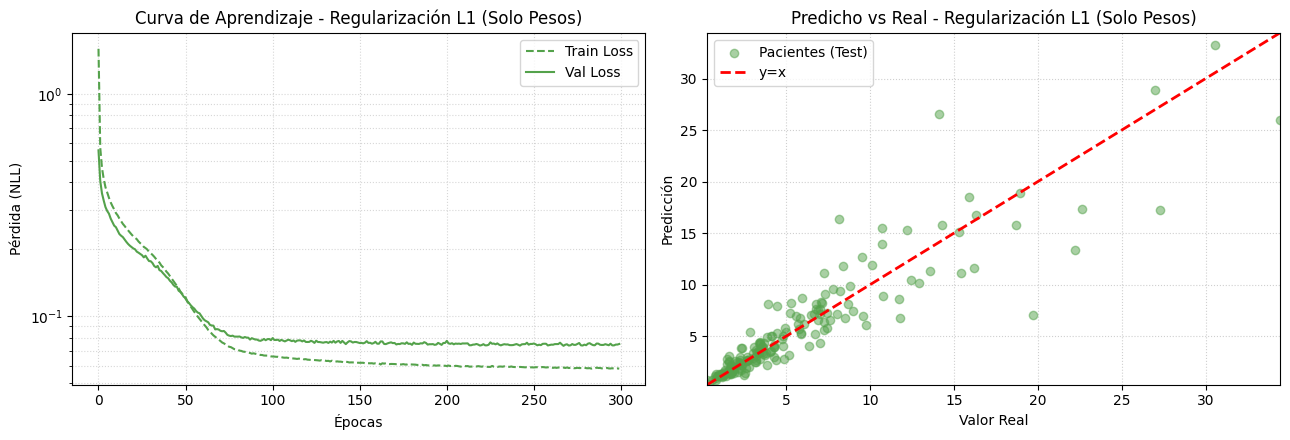

In [35]:
inicio = time.time()
modelo_l1, hist_l1 = entrenar_l1_solo_pesos(n_hidden=16)
tiempo = time.time() - inicio

evaluar_y_graficar(modelo_l1, hist_l1, tiempo, "Regularización L1 (Solo Pesos)", "#54a24b")


[Early Stopping] Detenido en la época 168. Restaurando mejores pesos.

REPORTE: EARLY STOPPING EXCLUSIVO (PARADA ÉPOCA 168)
Parámetros Entrenables: 113
Tiempo de Entrenamiento: 4.17 segundos
MAE:  1.3946
RMSE: 2.4639
Error Relativo Medio: 24.77%


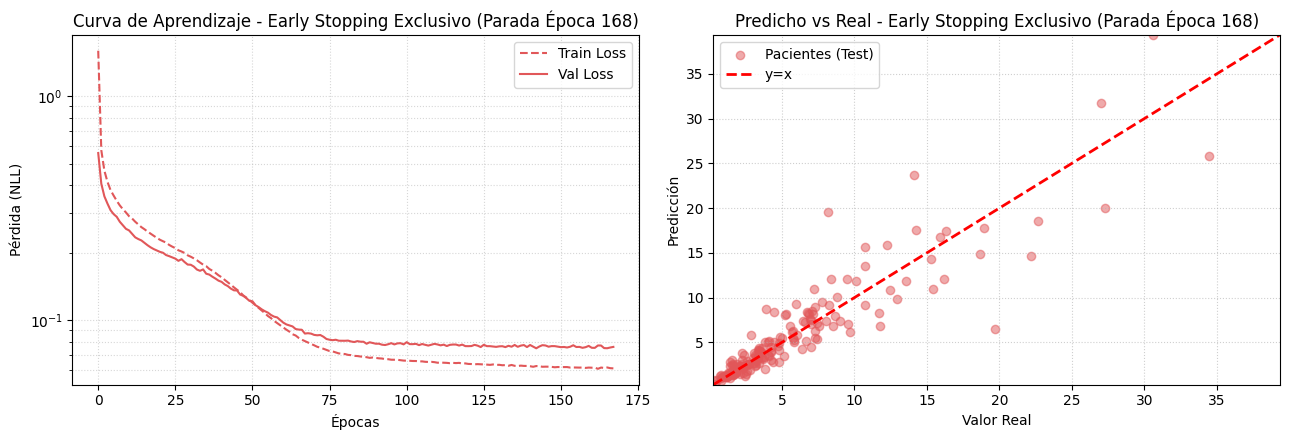

In [36]:
import copy
inicio = time.time()
modelo_es, hist_es, epoca_stop_es = entrenar_early_stopping(n_hidden=16)
tiempo = time.time() - inicio

evaluar_y_graficar(modelo_es, hist_es, tiempo, f"Early Stopping Exclusivo (Parada Época {epoca_stop_es})", "#e15759")

In [37]:
params_es_pytorch = {
    'W1': modelo_es.capa_oculta.weight.detach().cpu().numpy(),
    'W2': modelo_es.capa_salida.weight.detach().cpu().numpy()
}

MÉTRICAS DE MAGNITUD DE PESOS (FROM SCRATCH)
Norma Global Frobenius (SIN Regularizar): 11.3016
Norma Global Frobenius (CON Regularizar): 5.5720
Reducción absoluta de la norma: 5.7296
Porcentaje de compresión de pesos: 50.70%


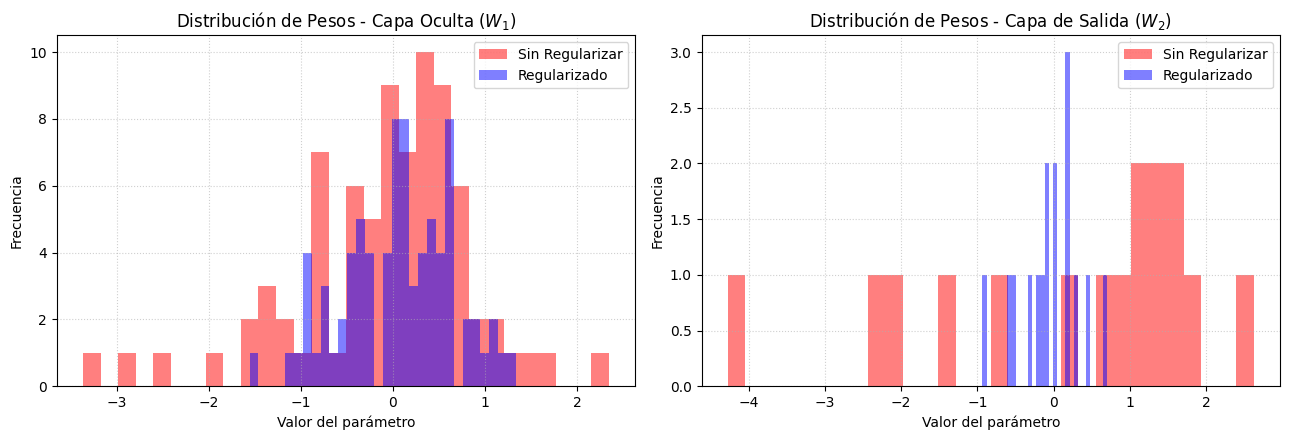

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def comparar_pesos_scratch(params_sin_reg, params_con_reg):
    """
    Calcula la norma global de Frobenius y grafica la distribución de pesos
    para los modelos 'from scratch' sin y con regularización.
    """
    # 1. Extraer las matrices de pesos de ambos modelos (se omiten los sesgos/biases)
    W1_sin = params_sin_reg['W1']
    W2_sin = params_sin_reg['W2']

    W1_con = params_con_reg['W1']
    W2_con = params_con_reg['W2']

    # 2. Calcular la Norma de Frobenius Global (L2 matricial) para cada modelo
    # ||W||_F = sqrt( sum(w_ij^2) )
    norma_global_sin = np.sqrt(np.sum(W1_sin**2) + np.sum(W2_sin**2))
    norma_global_con = np.sqrt(np.sum(W1_con**2) + np.sum(W2_con**2))

    # Reporte numérico en consola
    print("="*60)
    print("MÉTRICAS DE MAGNITUD DE PESOS (FROM SCRATCH)")
    print("="*60)
    print(f"Norma Global Frobenius (SIN Regularizar): {norma_global_sin:.4f}")
    print(f"Norma Global Frobenius (CON Regularizar): {norma_global_con:.4f}")
    print(f"Reducción absoluta de la norma: {norma_global_sin - norma_global_con:.4f}")
    print(f"Porcentaje de compresión de pesos: {((norma_global_sin - norma_global_con)/norma_global_sin)*100:.2f}%")
    print("="*60)

    # 3. Visualización de la distribución mediante histogramas por capa
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    # Distribución en la Capa Oculta (W1)
    ax1.hist(W1_sin.flatten(), bins=30, alpha=0.5, color='red', label='Sin Regularizar')
    ax1.hist(W1_con.flatten(), bins=30, alpha=0.5, color='blue', label='Regularizado')
    ax1.set_title('Distribución de Pesos - Capa Oculta ($W_1$)')
    ax1.set_xlabel('Valor del parámetro')
    ax1.set_ylabel('Frecuencia')
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.6)

    # Distribución en la Capa de Salida (W2)
    ax2.hist(W2_sin.flatten(), bins=30, alpha=0.5, color='red', label='Sin Regularizar')
    ax2.hist(W2_con.flatten(), bins=30, alpha=0.5, color='blue', label='Regularizado')
    ax2.set_title('Distribución de Pesos - Capa de Salida ($W_2$)')
    ax2.set_xlabel('Valor del parámetro')
    ax2.set_ylabel('Frecuencia')
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()


comparar_pesos_scratch(params_B, params_es_pytorch)

### Responda
1. ¿Qué estrategia redujo más la brecha entre pérdida de entrenamiento y validación?
- Todos tuvieron un desempeño similar a excepción de dropout, método el cual aumenta la brecha
2.  ¿Qué estrategia mejoró más el desempeño en prueba?
- L1 fue la estrategia que redujo mas el error
3. ¿Qué estrategia empeoró el desempeño y por qué?
- Dropout, esto probablemente se deba al tamaño de la red. Esta es una red pequeña, al quitarle más neuronas, se pierde capacidad para representar la función no lineal del biomarcador
4. ¿Qué diferencias observa entre regularización explícita, como
, y regularización implícita inducida por SGD?
5. ¿Cómo cambia el resultado al modificar el tamaño de minibatch manteniendo fija la arquitectura?
6. ¿En qué casos el early stopping se comporta de manera similar a una penalización
?
7. ¿Existe evidencia de doble descenso o de una relación no monótona entre capacidad y error de prueba?
- No
8. Si usa dropout, ¿cómo cambia el comportamiento cuando aumenta la probabilidad de apagar unidades?
- El modelo experimenta una pérdida crítica en su capacidad de representación. La red no logra retener suficientes vías de activación simultáneas para procesar las combinaciones de las variables de entrada, provocando que la pérdida de entrenamiento aumente
9. Para la red implementada from scratch, compare las magnitudes de los pesos del modelo sin regularización y del modelo regularizado. Reporte al menos una norma global de los pesos, por ejemplo
 o
, y una visualización de la distribución de pesos por capa. ¿La regularización produjo pesos de menor magnitud? ¿El efecto fue igual en todas las capas?



### Efectos con Ruido

**Con 0.25**: Efectos del presente Notebook

**Con 0.10**
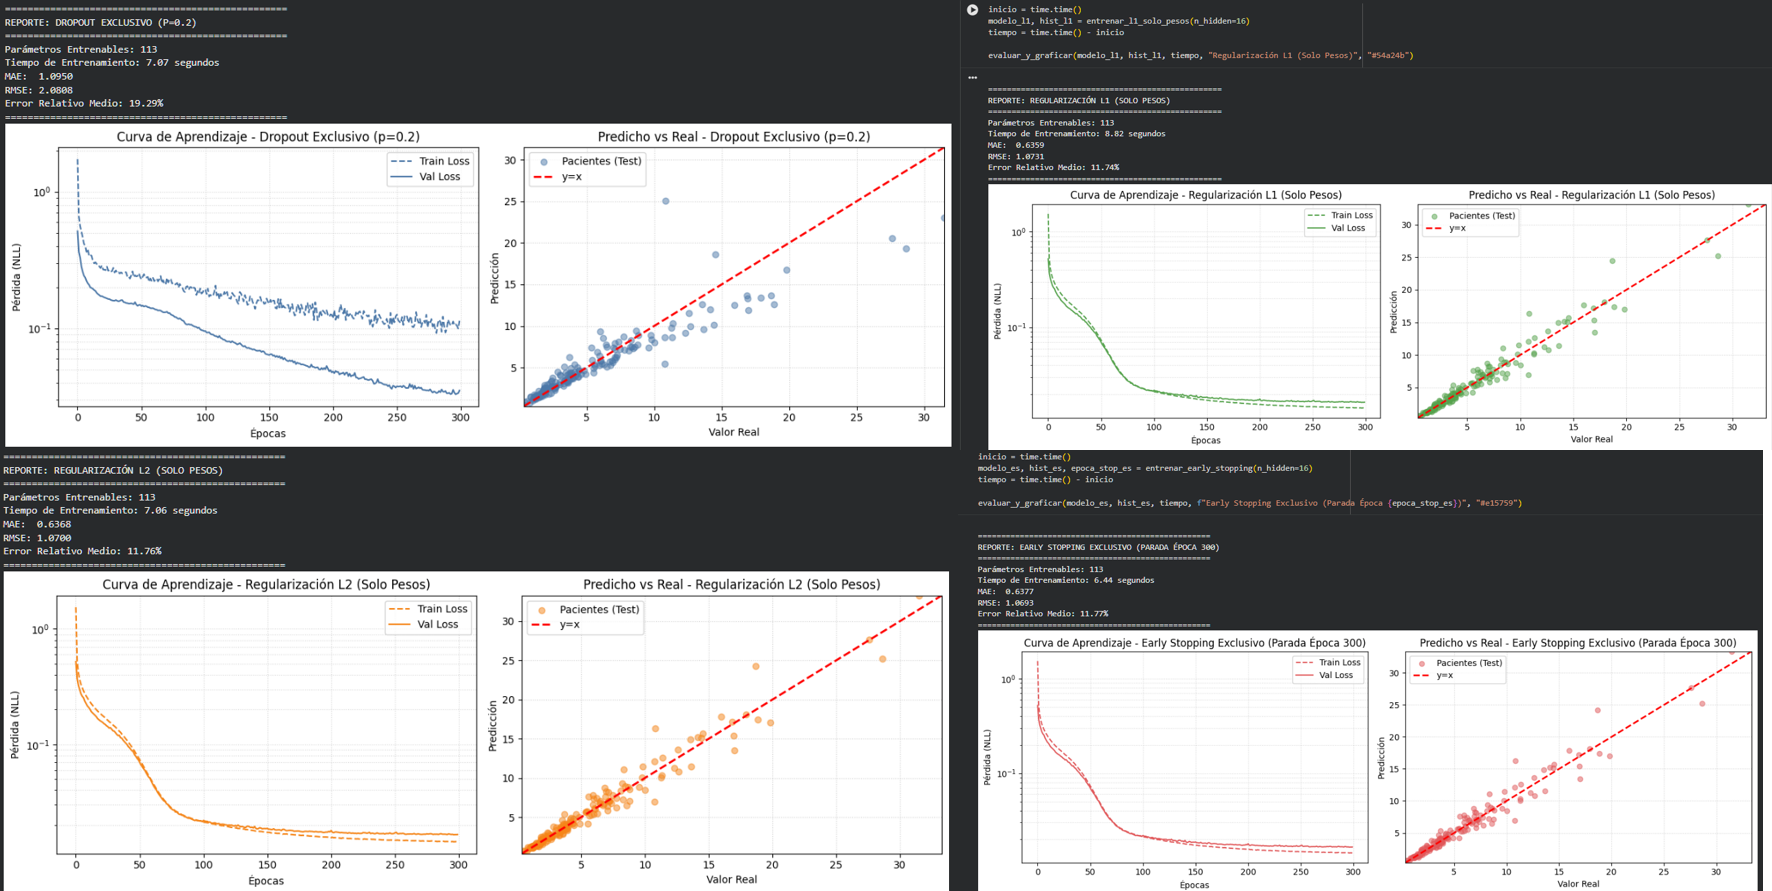

**Con 0.50**

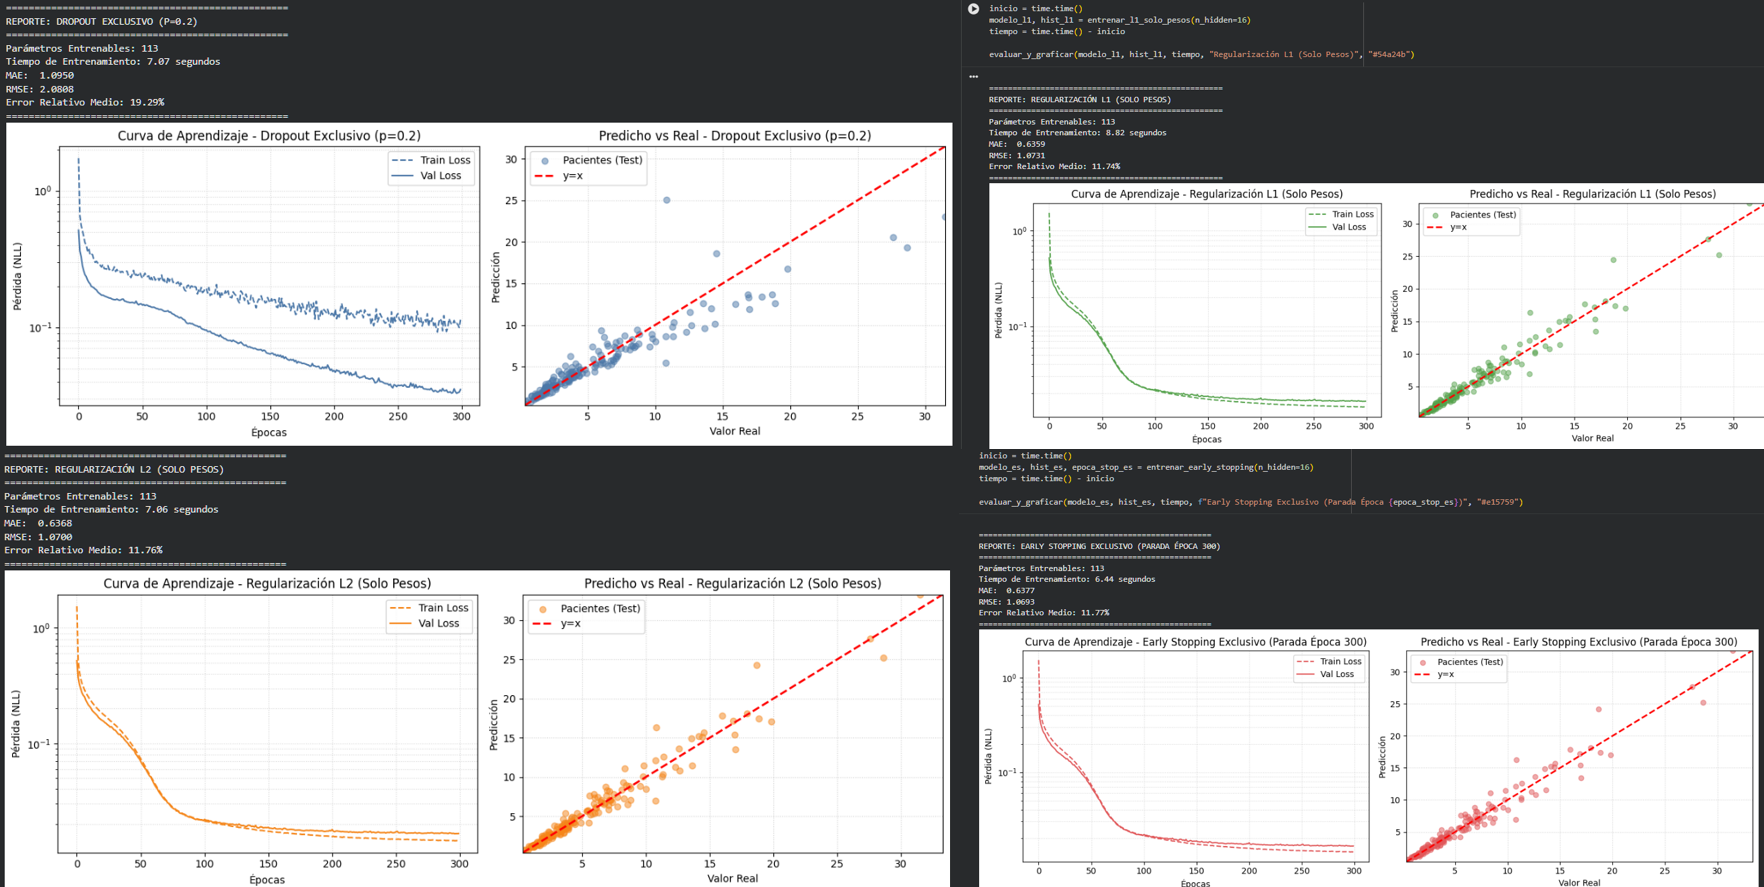

Todas las arquitecturas tienen un cambio proporcional en los errores, no se evidencian mayores sensibilidades.

## Responder

### 1. ¿Por qué una red con ReLU implementa una función lineal por partes?

Es una función lineal por tramos, con pendiente 0 para valores negativos y 1 para valores positivos. Al combinar linealmente estas funciones capa tras capa, el espacio de entrada se subdivide en múltiples regiones. Dentro de cada región, la combinación de neuronas activas e inactivas permanece fija, lo que hace que la función global de la red sea una función continua y **lineal por partes**.

### 2. ¿Qué información debe guardarse durante el *forward pass* para poder ejecutar *backpropagation* eficientemente?

Se deben almacenar las **activaciones intermedias** ($a$) y/o las pre-activaciones ($z$) de cada capa, además de los datos de entrada. Esto es indispensable porque, al aplicar la regla de la cadena en el *backpropagation*, el cálculo de los gradientes de la función de pérdida respecto a los pesos y sesgos depende directamente de los valores que tomaron esas variables en el paso hacia adelante. Al guardarlos en memoria, se evita tener que recalcular el *forward pass*.

### 3. ¿Por qué una red suficientemente grande puede tener pérdida de entrenamiento casi cero y aun así generalizar mal?

Este fenómeno es el **sobreajuste (overfitting)**. Una red con una capacidad excesiva tiene la flexibilidad necesaria para memorizar las particularidades, el ruido y los datos atípicos del conjunto de entrenamiento en lugar de aprender la distribución o el patrón. Como consecuencia, optimiza la pérdida de entrenamiento hasta dejarla en cero, pero falla al enfrentarse a datos nuevos no vistos.

### 4. ¿Qué rol cumple el conjunto de validación en la selección de hiperparámetros?

Actúa como un estimador independiente del error de generalización para diferentes configuraciones de un modelo. Permite evaluar y comparar el rendimiento bajo distintos hiperparámetros para seleccionar la combinación óptima. Esto evita el sesgo de optimizar los hiperparámetros directamente sobre el conjunto de entrenamiento o de "contaminar" el conjunto de prueba.

### 5. ¿Por qué no se debe usar el conjunto de prueba para decidir cuándo detener el entrenamiento?

Porque introduce una **filtración de datos (data leakage)**. Si el criterio de parada (como el *early stopping*) depende del rendimiento en el conjunto de prueba, dicho conjunto pasa a formar parte indirecta del proceso de entrenamiento. Al final, el modelo estará sesgado hacia esos datos particulares, invalidando al conjunto de prueba como una métrica objetiva e independiente para medir la capacidad de generalización real del modelo.

### 6. ¿Qué diferencia práctica hay entre minimizar MSE y minimizar una NLL derivada de una distribución log-normal?

* **Minimizar MSE:** Equivale a una estimación de máxima verosimilitud asumiendo que los errores siguen una distribución Normal. Penaliza con base en el error absoluto al cuadrado, siendo muy sensible a valores atípicos grandes.
* **Minimizar NLL (Log-Normal):** Asume que el logaritmo de la variable sigue una distribución Normal. En la práctica, es ideal para variables estrictamente positivas y asimétricas hacia la derecha; penaliza los **errores relativos o proporcionales** en lugar de los absolutos, evitando que los valores atípicos de gran magnitud dominen por completo el gradiente.

### 7. Si dos modelos tienen RMSE similar, pero uno nunca predice valores negativos, ¿cuál preferiría para este problema y por qué?

Se preferiría el modelo que **nunca predice valores negativos**. Dado que el dominio del problema es exclusivamente de valores positivos

### 8. ¿Cómo se interpreta la regularización $\ell_2$ desde una perspectiva probabilística MAP?

La regularización $\ell_2$  equivale exactamente a realizar una estimación de Máximo A Posteriori (MAP) bajo el supuesto de que los pesos del modelo siguen una **distribución a priori Gaussiana** con media cero. Al aplicar el logaritmo a la función a posteriori, el término que corresponde a la densidad de esta distribución *prior* se traduce matemáticamente en la penalización cuadrática de la norma de los pesos:

$$\arg\max_W \log P(W|X) \propto \arg\max_W \left[ \log P(X|W) - \frac{\lambda}{2} \|W\|_2^2 \right]$$

### 9. ¿Por qué usualmente se regularizan los pesos, pero no los sesgos?

Los pesos determinan la pendiente y la curvatura de la función de activación en cada dimensión; valores elevados de los pesos implican una alta sensibilidad a pequeñas variaciones de la entrada, induciendo varianza y sobreajuste. En cambio, los sesgos (*biases*) solo controlan el desplazamiento horizontal de las funciones y representan un único parámetro por neurona. Restringirlos no combate el sobreajuste y, por el contrario, suele limitar innecesariamente la capacidad del modelo para ajustarse al desfase base (*offset*) de los datos.

### 10. ¿Qué costo computacional se tiene al usar un ensamble y cuándo se justificaría?

* **Costo computacional:** El costo aumenta de forma lineal $N$ veces (donde $N$ es el número de modelos del ensamble), impactando directamente el tiempo de entrenamiento, el tiempo de inferencia (latencia) y los requisitos de memoria y almacenamiento.
* **Cuándo se justifica:** Se justifica en aplicaciones críticas donde la precisión, la robustez y la correcta calibración de la incertidumbre son prioritarias sobre el costo (por ejemplo, en sistemas de diagnóstico médico, análisis de fallos de alto riesgo o fases finales de competencias de ciencia de datos) y cuando el entorno de producción no cuenta con restricciones severas de tiempo real o hardware limitado.

# Red neuronal con salidas mixtas

Datos

In [40]:
# Fijamos semilla para reproducibilidad clínica
np.random.seed(42)

def generar_etiquetas_mixtas(y_original):
    # 1. Salida Continua: Un puntaje de salud continuo (con ruido)
    y_cont = y_original * 0.7 + np.random.normal(0, 1, size=y_original.shape)

    # 2. Salida Categórica: Clasificación en 3 estados según la concentración del biomarcador
    # Menor a 4: Estable (0) | Entre 4 y 12: Observación (1) | Mayor a 12: Crítico (2)
    y_cat = np.zeros(y_original.shape[1], dtype=np.int64)
    y_cat[y_original.flatten() >= 4.0] = 1
    y_cat[y_original.flatten() >= 12.0] = 2

    return y_cont, y_cat

# Generar para cada conjunto
y_train_cont, y_train_cat = generar_etiquetas_mixtas(y_train)
y_val_cont, y_val_cat = generar_etiquetas_mixtas(y_val)
y_test_cont, y_test_cat = generar_etiquetas_mixtas(y_test)

# Convertir a tensores de PyTorch
y_train_cont_t = torch.tensor(y_train_cont.T, dtype=torch.float32)
y_train_cat_t = torch.tensor(y_train_cat, dtype=torch.long) # Long es obligatorio para clasificación en PyTorch

y_val_cont_t = torch.tensor(y_val_cont.T, dtype=torch.float32)
y_val_cat_t = torch.tensor(y_val_cat, dtype=torch.long)

y_test_cont_t = torch.tensor(y_test_cont.T, dtype=torch.float32)
y_test_cat_t = torch.tensor(y_test_cat, dtype=torch.long)

# Crear un DataLoader robusto con las 3 respuestas simultáneas
dataset_multitarea = TensorDataset(X_train_torch, y_train_torch, y_train_cont_t, y_train_cat_t)
train_loader_multi = DataLoader(dataset_multitarea, batch_size=32, shuffle=True)

Red

In [41]:
class RedNeuronalMultitarea(nn.Module):
    def __init__(self, n_entrada, n_ocultas=32):
        super(RedNeuronalMultitarea, self).__init__()

        # Tronco Compartido (Backbone)
        self.tronco_compartido = nn.Sequential(
            nn.Linear(n_entrada, n_ocultas),
            nn.ReLU(),
            nn.Dropout(p=0.2)
        )

        # Cabezal 1: Regresión Continua (1 neurona de salida lineal)
        self.cabeza_continua = nn.Linear(n_ocultas, 1)

        # Cabezal 2: Regresión Positiva Log-Normal (1 neurona de salida lineal para mu)
        self.cabeza_positiva = nn.Linear(n_ocultas, 1)

        # Cabezal 3: Clasificación Categórica (3 neuronas, una para cada clase: 0, 1, 2)
        self.cabeza_categorica = nn.Linear(n_ocultas, 3)

    def forward(self, x):
        # Pasar por las capas comunes
        caracteristicas = self.tronco_compartido(x)

        # Dividir el flujo en las 3 tareas independientes
        out_continuo = self.cabeza_continua(caracteristicas)
        out_positivo = self.cabeza_positiva(caracteristicas) # Este es el parámetro mu
        out_categorico = self.cabeza_categorica(caracteristicas) # Devuelve logits sin Softmax

        return out_continuo, out_positivo, out_categorico

Entrenamiento

In [42]:
def entrenar_red_multitarea(epocas=150, learning_rate=0.01):
    torch.manual_seed(42)
    modelo = RedNeuronalMultitarea(n_entrada=5, n_ocultas=32)
    optimizador = optim.Adam(modelo.parameters(), lr=learning_rate) # Usamos Adam para facilitar la convergencia mixta

    # Funciones de pérdida específicas
    criterio_mse = nn.MSELoss()
    criterio_cross_entropy = nn.CrossEntropyLoss() # Aplica Softmax internamente

    for epoca in range(1, epocas + 1):
        modelo.train()
        loss_total_acumulada = 0.0

        for X_b, y_pos_b, y_cont_b, y_cat_b in train_loader_multi:
            optimizador.zero_grad()

            # Forward pass triple
            pred_cont, pred_mu_pos, logits_cat = modelo(X_b)

            # Calcular las 3 pérdidas
            loss_1 = criterio_mse(pred_cont, y_cont_b)
            loss_2 = perdida_nll_lognormal(pred_mu_pos, y_pos_b)
            loss_3 = criterio_cross_entropy(logits_cat, y_cat_b)

            # Combinación lineal de pérdidas (Pérdida Total)
            loss_total = loss_1 + loss_2 + loss_3

            # Un solo backward calcula los gradientes de todo el sistema combinado
            loss_total.backward()
            optimizador.step()

            loss_total_acumulada += loss_total.item() * X_b.size(0)

        if epoca % 20 == 0 or epoca == 1:
            loss_promedio = loss_total_acumulada / X_train_torch.size(0)
            print(f"Época {epoca:03d}/{epocas} -> Pérdida Multitarea Combinada: {loss_promedio:.4f}")

    return modelo

print("Iniciando el entrenamiento de la Red Multitarea...")
modelo_multi = entrenar_red_multitarea(epocas=150)

Iniciando el entrenamiento de la Red Multitarea...
Época 001/150 -> Pérdida Multitarea Combinada: 26.4696
Época 020/150 -> Pérdida Multitarea Combinada: 5.1994
Época 040/150 -> Pérdida Multitarea Combinada: 4.6023
Época 060/150 -> Pérdida Multitarea Combinada: 4.4301
Época 080/150 -> Pérdida Multitarea Combinada: 4.3809
Época 100/150 -> Pérdida Multitarea Combinada: 4.1459
Época 120/150 -> Pérdida Multitarea Combinada: 4.2741
Época 140/150 -> Pérdida Multitarea Combinada: 4.3897


Evaluación

In [43]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

modelo_multi.eval()
with torch.no_grad():
    pred_cont_t, pred_mu_pos_t, logits_cat_t = modelo_multi(X_test_torch)

    # Procesar salida categórica: Tomar el índice con la probabilidad más alta (Argmax)
    clases_predichas = torch.argmax(logits_cat_t, dim=1).numpy()
    clases_reales = y_test_cat_t.numpy()

# Calcular métricas de clasificación
acc = accuracy_score(clases_reales, clases_predichas)
matriz = confusion_matrix(clases_reales, clases_predichas)

print("\n" + "="*50)
print(f"EVALUACIÓN DEL CABEZAL CATEGÓRICO (TEST) - Exactitud: {acc*100:.2f}%")
print("="*50)
print("Matriz de Confusión:")
print(matriz)
print("\nReporte de Clasificación Clínico:")
print(classification_report(clases_reales, clases_predichas, target_names=["Estable", "Observación", "Crítico"]))


EVALUACIÓN DEL CABEZAL CATEGÓRICO (TEST) - Exactitud: 85.00%
Matriz de Confusión:
[[89  5  0]
 [12 50  4]
 [ 0  6 14]]

Reporte de Clasificación Clínico:
              precision    recall  f1-score   support

     Estable       0.88      0.95      0.91        94
 Observación       0.82      0.76      0.79        66
     Crítico       0.78      0.70      0.74        20

    accuracy                           0.85       180
   macro avg       0.83      0.80      0.81       180
weighted avg       0.85      0.85      0.85       180



# Referencias
- [Presentaciones del curso](https://aavelozb.github.io/bme513/index.html)
-  [Building a neural network FROM SCRATCH (no Tensorflow/Pytorch, just numpy & math)](https://www.youtube.com/watch?v=w8yWXqWQYmU)
- [Neural Network from Scratch | Mathematics & Python Code](https://www.youtube.com/watch?v=pauPCy_s0Ok)
- [Neural Network From Scratch: No Pytorch & Tensorflow; just pure math | 30 min theory + 30 min coding](https://www.youtube.com/watch?v=A83BbHFoKb8)
- Pattern Recognition and Machine Learning, Christopher Bishop, pag 140 (MLE)
- [Log normal distribution](https://en.wikipedia.org/wiki/Log-normal_distribution)
- [Inicializción He](https://towardsdatascience.com/kaiming-he-initialization-in-neural-networks-math-proof-73b9a0d845c4/)
- [Tablas](https://matplotlib.org/matplotblog/posts/how-to-create-custom-tables/)